In [1]:
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
import matplotlib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import warnings
from datetime import datetime as dt
import time
import tqdm
import scipy
import csv
from sklearn.metrics import mean_squared_error,mean_absolute_error
import xgboost as xgb
from sklearn.feature_selection import RFE
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"C:\Users\HP\Downloads\DummyARData.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8052 entries, 0 to 8051
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cms_doc_header_id   8052 non-null   int64  
 1   fk_customer_map_id  8052 non-null   int64  
 2   amount              8052 non-null   float64
 3   due_date            8052 non-null   object 
 4   clearing_date       8052 non-null   object 
 5   create_date         8052 non-null   object 
 6   baseline_date_norm  8052 non-null   object 
 7   mega_date           8052 non-null   object 
 8   payment terms       8052 non-null   object 
 9   payment mode        8052 non-null   object 
dtypes: float64(1), int64(2), object(7)
memory usage: 629.2+ KB


In [4]:
df.shape

(8052, 10)

In [5]:
df.head()

,cms_doc_header_id,fk_customer_map_id,amount,due_date,clearing_date,create_date,baseline_date_norm,mega_date,payment terms,payment mode
0,563896,103038959,207.22,1/29/2021,2/11/2021,12/30/2020,12/30/2020,12/30/2020,ZZ28,Cash
1,2508425,103023803,17722.32,2/23/2020,2/18/2020,1/24/2020,1/24/2020,1/24/2020,Z071,Credit Card
2,1328525,102950241,2126.49,9/22/2020,9/29/2020,8/21/2020,8/23/2020,8/23/2020,Z071,Cheque
3,5617210,102988674,187.47,12/21/2019,12/30/2019,11/18/2019,11/21/2019,11/21/2019,ZZ28,Cash
4,8566176,103047205,576.08,10/1/2020,9/21/2020,8/28/2020,9/1/2020,9/1/2020,ZZ63,Cheque


In [6]:
df.tail()

,cms_doc_header_id,fk_customer_map_id,amount,due_date,clearing_date,create_date,baseline_date_norm,mega_date,payment terms,payment mode
8047,3427299,102988674,20.55,10/11/2020,10/13/2020,9/9/2020,9/11/2020,9/11/2020,Z536,Net banking
8048,5424477,102988674,715.98,8/20/2020,8/24/2020,7/16/2020,7/21/2020,7/21/2020,ZZ63,Cheque
8049,3145597,102906533,552.94,3/5/2021,2/24/2021,1/29/2021,2/3/2021,2/3/2021,ZZ63,Cheque
8050,6675904,102988674,45.85,5/11/2021,5/17/2021,4/9/2021,4/11/2021,4/11/2021,Z536,Net banking
8051,4262187,102906533,46.93,2/13/2021,1/28/2021,1/12/2021,1/14/2021,1/14/2021,Z536,Net banking


In [7]:
df['due_date'] = pd.to_datetime(df['due_date'],format='%m/%d/%Y')
df['clearing_date'] = pd.to_datetime(df['clearing_date'],format='%m/%d/%Y')
df['create_date'] = pd.to_datetime(df['create_date'],format='%m/%d/%Y')
df['baseline_date_norm'] = pd.to_datetime(df['baseline_date_norm'],format='%m/%d/%Y')
df['mega_date'] = pd.to_datetime(df['mega_date'],format='%m/%d/%Y')


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8052 entries, 0 to 8051
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   cms_doc_header_id   8052 non-null   int64         
 1   fk_customer_map_id  8052 non-null   int64         
 2   amount              8052 non-null   float64       
 3   due_date            8052 non-null   datetime64[ns]
 4   clearing_date       8052 non-null   datetime64[ns]
 5   create_date         8052 non-null   datetime64[ns]
 6   baseline_date_norm  8052 non-null   datetime64[ns]
 7   mega_date           8052 non-null   datetime64[ns]
 8   payment terms       8052 non-null   object        
 9   payment mode        8052 non-null   object        
dtypes: datetime64[ns](5), float64(1), int64(2), object(2)
memory usage: 629.2+ KB


In [9]:
df.head()

,cms_doc_header_id,fk_customer_map_id,amount,due_date,clearing_date,create_date,baseline_date_norm,mega_date,payment terms,payment mode
0,563896,103038959,207.22,2021-01-29,2021-02-11,2020-12-30,2020-12-30,2020-12-30,ZZ28,Cash
1,2508425,103023803,17722.32,2020-02-23,2020-02-18,2020-01-24,2020-01-24,2020-01-24,Z071,Credit Card
2,1328525,102950241,2126.49,2020-09-22,2020-09-29,2020-08-21,2020-08-23,2020-08-23,Z071,Cheque
3,5617210,102988674,187.47,2019-12-21,2019-12-30,2019-11-18,2019-11-21,2019-11-21,ZZ28,Cash
4,8566176,103047205,576.08,2020-10-01,2020-09-21,2020-08-28,2020-09-01,2020-09-01,ZZ63,Cheque


In [10]:
df.isna().sum()

cms_doc_header_id     0
fk_customer_map_id    0
amount                0
due_date              0
clearing_date         0
create_date           0
baseline_date_norm    0
mega_date             0
payment terms         0
payment mode          0
dtype: int64

In [11]:
df.nunique()

cms_doc_header_id     8052
fk_customer_map_id     136
amount                6656
due_date               705
clearing_date          494
create_date            630
baseline_date_norm     681
mega_date              681
payment terms            8
payment mode             4
dtype: int64

In [12]:
df['baseline_date_norm'].dt.year.value_counts()

baseline_date_norm
2020    4651
2021    2564
2019     837
Name: count, dtype: int64

In [13]:
(df['baseline_date_norm'] > df['create_date']).sum()

4072

In [14]:
(df['baseline_date_norm'] > df['due_date']).sum()

0

In [15]:
(df['amount']<=0).sum()

0

In [16]:
df = df[df['baseline_date_norm'] <= df['clearing_date']]

In [17]:
df['baseline_date_norm'].min()

Timestamp('2019-11-01 00:00:00')

In [18]:
df = df[df['baseline_date_norm'] > '2019-10-31']

In [19]:
df.shape

(8052, 10)

In [20]:
df['baseline_date_norm'].dt.year.value_counts()

baseline_date_norm
2020    4651
2021    2564
2019     837
Name: count, dtype: int64

In [21]:
df['delay'] = (df['clearing_date'] - df['due_date']).dt.days

<Axes: xlabel='baseline_date_norm', ylabel='delay'>

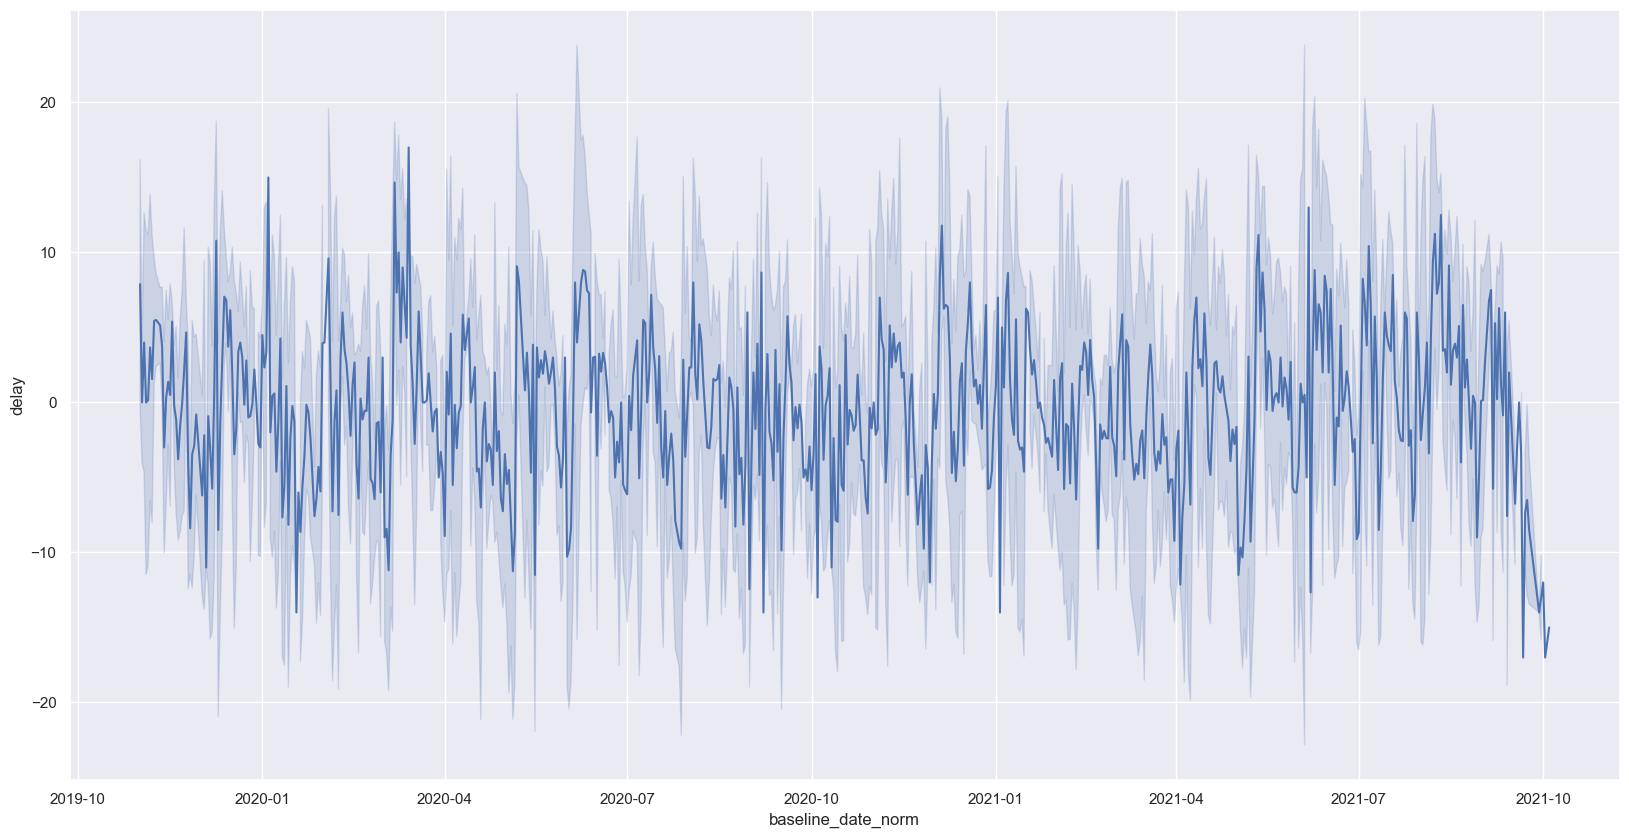

In [22]:
sns.set(rc={'figure.figsize':(20,10)})
sns.lineplot(x='baseline_date_norm',y='delay',data=df,ci='sd')

In [23]:
df['payment_time'] = (df['due_date'] - df['baseline_date_norm']).dt.days

In [24]:
df['baseline_date_norm'][df['baseline_date_norm'].dt.year == 2019].dt.month.value_counts()

baseline_date_norm
12    435
11    402
Name: count, dtype: int64

In [25]:
df['baseline_date_norm'][df['baseline_date_norm'].dt.year == 2020].dt.month.value_counts()

baseline_date_norm
1     492
10    470
9     443
2     440
7     413
3     376
12    359
6     349
4     341
8     331
11    327
5     310
Name: count, dtype: int64

In [26]:
df['baseline_date_norm'][df['baseline_date_norm'].dt.year == 2021].dt.month.value_counts()

baseline_date_norm
3     388
1     386
2     326
4     311
8     293
7     281
5     254
6     215
9     106
10      4
Name: count, dtype: int64

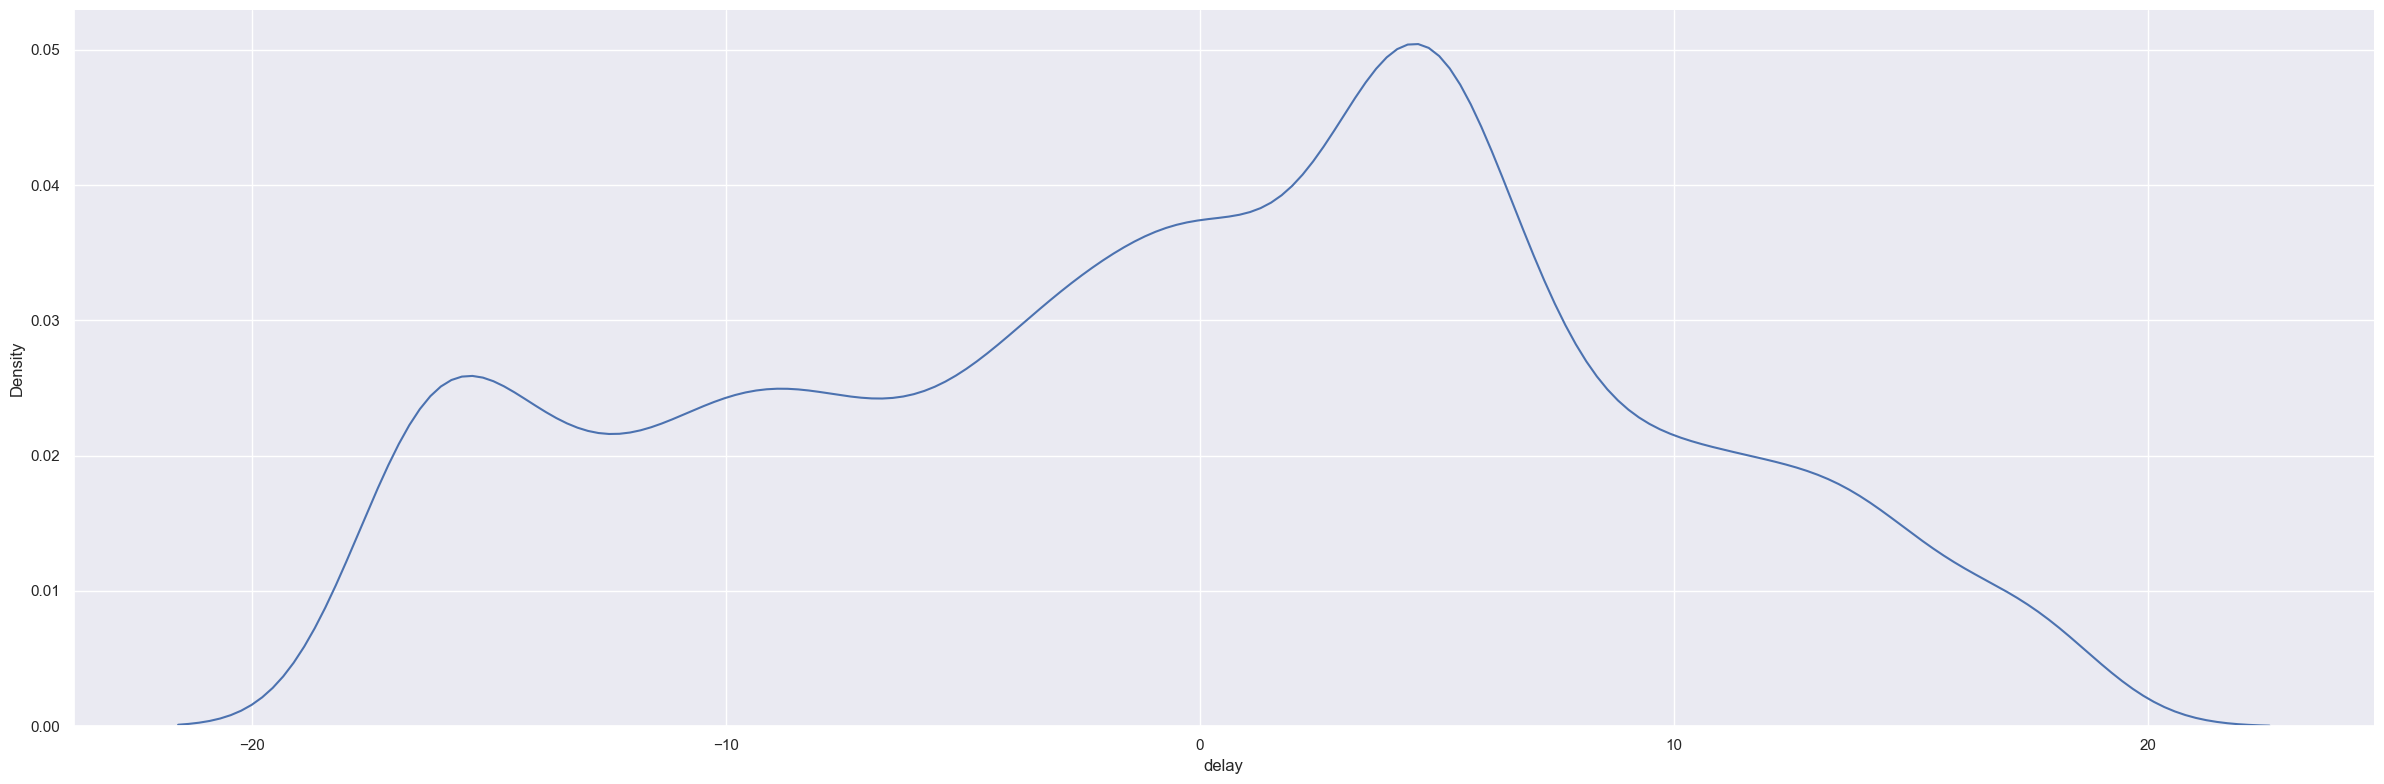

In [27]:

sns.set(rc={'figure.figsize':(20,10)})
sns.displot(df['delay'],height=8,aspect=3,kind='kde')

<Axes: xlabel='mega_date', ylabel='delay'>

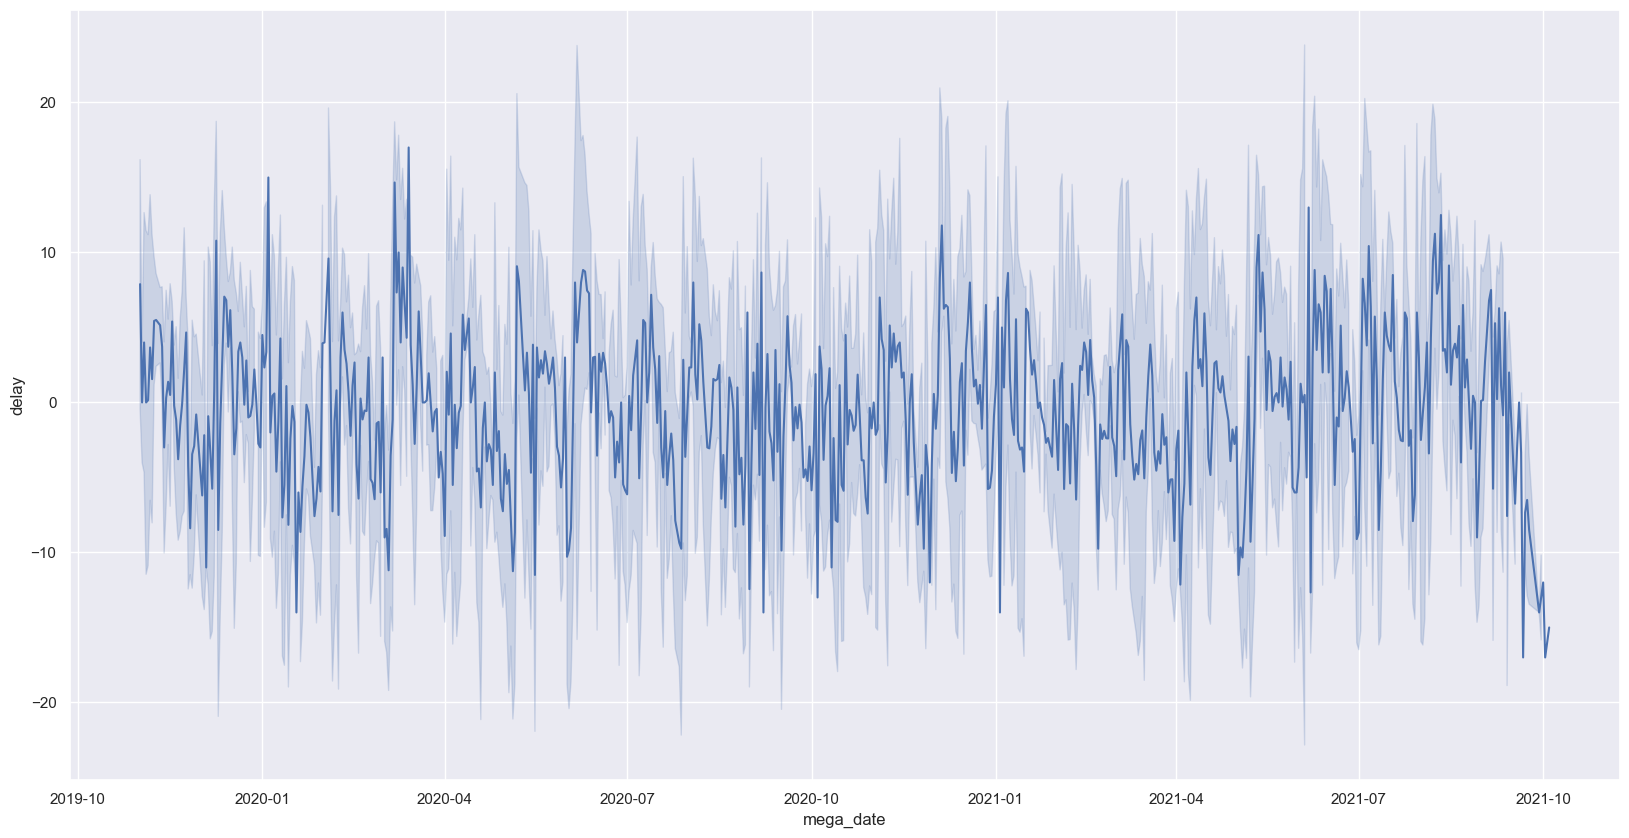

In [28]:
sns.lineplot(x='mega_date',y='delay',data=df,ci='sd')

<Axes: xlabel='delay', ylabel='Density'>

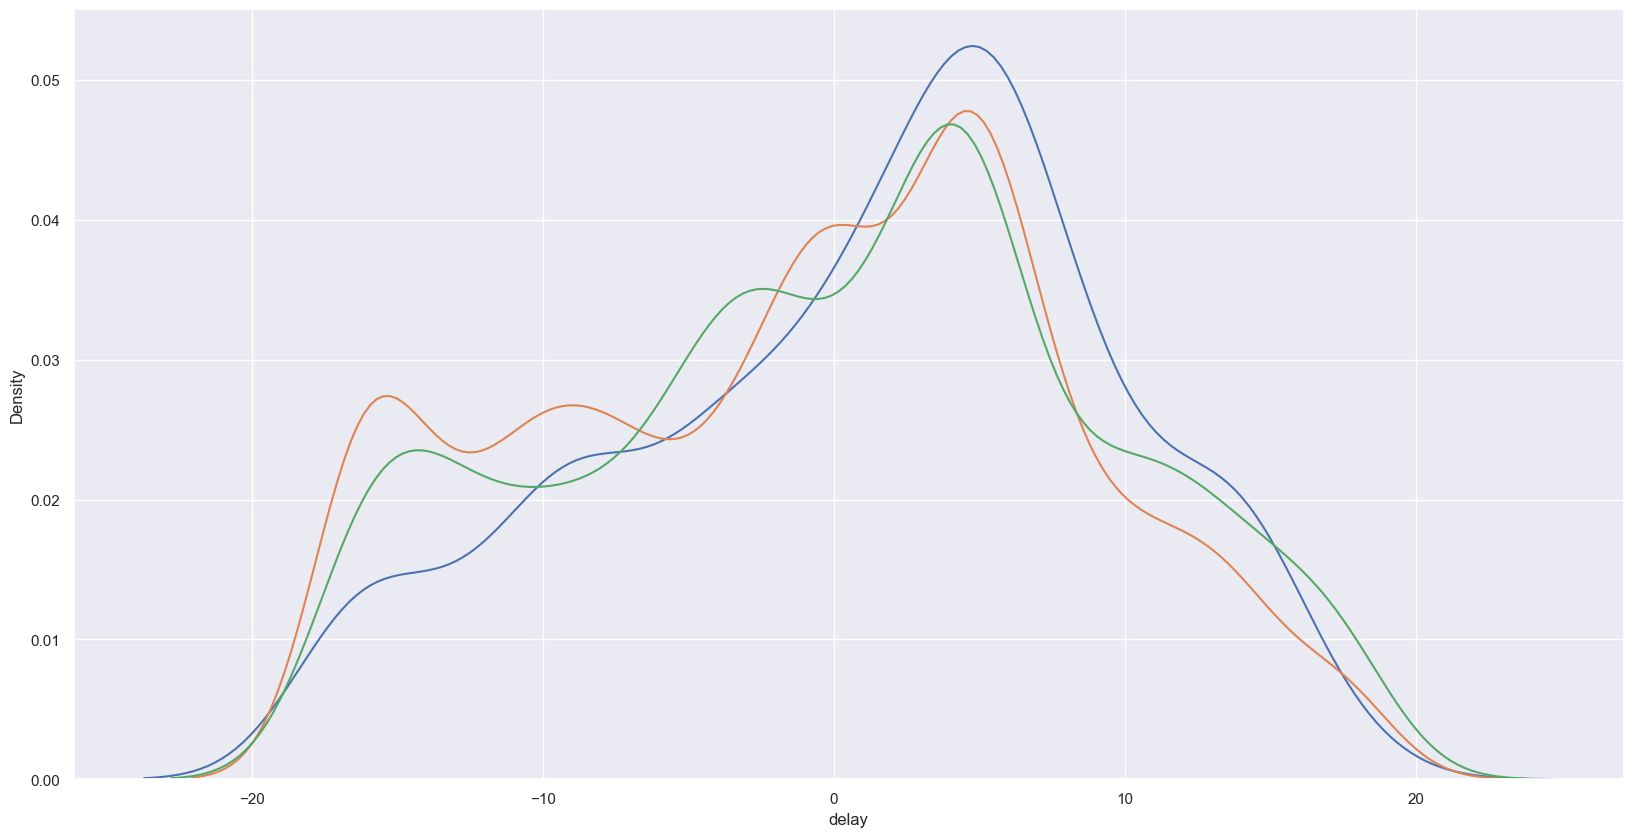

In [29]:
sns.distplot(df['delay'][df['baseline_date_norm'].dt.year==2019],hist=False)
sns.distplot(df['delay'][df['baseline_date_norm'].dt.year==2020],hist=False)
sns.distplot(df['delay'][df['baseline_date_norm'].dt.year==2021],hist=False)

In [30]:
df.head()

,cms_doc_header_id,fk_customer_map_id,amount,due_date,clearing_date,create_date,baseline_date_norm,mega_date,payment terms,payment mode,delay,payment_time
0,563896,103038959,207.22,2021-01-29,2021-02-11,2020-12-30,2020-12-30,2020-12-30,ZZ28,Cash,13,30
1,2508425,103023803,17722.32,2020-02-23,2020-02-18,2020-01-24,2020-01-24,2020-01-24,Z071,Credit Card,-5,30
2,1328525,102950241,2126.49,2020-09-22,2020-09-29,2020-08-21,2020-08-23,2020-08-23,Z071,Cheque,7,30
3,5617210,102988674,187.47,2019-12-21,2019-12-30,2019-11-18,2019-11-21,2019-11-21,ZZ28,Cash,9,30
4,8566176,103047205,576.08,2020-10-01,2020-09-21,2020-08-28,2020-09-01,2020-09-01,ZZ63,Cheque,-10,30


In [31]:
def find_skewed_boundaries(df, variable, distance):
    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)
    lower_boundary = df[variable].quantile(0.25) - (IQR * distance)
    upper_boundary = df[variable].quantile(0.75) + (IQR * distance)
    return upper_boundary, lower_boundary
upper_delay,lower_delay = find_skewed_boundaries(df,'delay',3)
upper_amount,lower_amount = find_skewed_boundaries(df,'amount',3)
print('Delay Capping are',lower_delay,upper_delay)
print('Amount Capping are',lower_amount,upper_amount)

Delay Capping are -50.0 48.0
Amount Capping are -26683.12 36181.815


In [32]:
print("If capping happens on delay",df[df.delay.between(lower_delay,upper_delay)].shape,"% of records =",1-df[df.delay.between(lower_delay,upper_delay)].shape[0]/df.shape[0])
print("If capping happens on delay",df[df.delay.between(lower_delay,upper_delay)].shape)
print("If capping happens on amount",df[df.amount.between(lower_amount,upper_amount)].shape,"% of records =",1-df[df.amount.between(lower_amount,upper_amount)].shape[0]/df.shape[0])
print("If capping happens on amount",df[df.amount.between(lower_amount,upper_amount)].shape)

If capping happens on delay (8052, 12) % of records = 0.0
If capping happens on delay (8052, 12)
If capping happens on amount (6985, 12) % of records = 0.13251366120218577
If capping happens on amount (6985, 12)


In [33]:
print('Amount Contribution is ',df[~df.delay.between(lower_delay, upper_delay)]['amount'].sum()/df['amount'].sum())
print('Invoice Contribution is ',df[~df.delay.between(lower_delay, upper_delay)].shape[0]/df['amount'].shape[0])

Amount Contribution is  0.0
Invoice Contribution is  0.0


In [34]:
df = df[df.delay.between(lower_delay,upper_delay)]

In [35]:
df.shape

(8052, 12)

In [36]:
def delay_buck(x):
    less_zero = '<=0'
    one_15 = '0-15'
    fifteen_30 = '15-30' 
    rest = '>30'
    if x<=0:
        return less_zero
    elif x>0 and x <= 15:
        return one_15
    elif x>15 and x<=30:
        return fifteen_30
    else:
        return rest
    
df["delay_bucket"] = df["delay"].apply(lambda x: delay_buck(x))

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8052 entries, 0 to 8051
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   cms_doc_header_id   8052 non-null   int64         
 1   fk_customer_map_id  8052 non-null   int64         
 2   amount              8052 non-null   float64       
 3   due_date            8052 non-null   datetime64[ns]
 4   clearing_date       8052 non-null   datetime64[ns]
 5   create_date         8052 non-null   datetime64[ns]
 6   baseline_date_norm  8052 non-null   datetime64[ns]
 7   mega_date           8052 non-null   datetime64[ns]
 8   payment terms       8052 non-null   object        
 9   payment mode        8052 non-null   object        
 10  delay               8052 non-null   int64         
 11  payment_time        8052 non-null   int64         
 12  delay_bucket        8052 non-null   object        
dtypes: datetime64[ns](5), float64(1), int64(4), obje

In [38]:
amount_contribution = df.groupby('delay_bucket')['amount'].sum().sort_values(ascending=False).to_frame(name='AMOUNT_USD_Total').reset_index()
invoice_contribution = df.groupby('delay_bucket')['fk_customer_map_id'].count().sort_values(ascending=False).to_frame(name='Count').reset_index()
amount_contribution

,delay_bucket,AMOUNT_USD_Total
0,<=0,1.401453e+09
1,0-15,2.937103e+08
2,15-30,3.869195e+07


In [39]:
invoice_contribution

,delay_bucket,Count
0,<=0,4056
1,0-15,3730
2,15-30,266


In [40]:
df.shape

(8052, 13)

In [41]:
print(df['amount'].sum())

1733854835.52


# EDA

In [42]:
df.head()

,cms_doc_header_id,fk_customer_map_id,amount,due_date,clearing_date,create_date,baseline_date_norm,mega_date,payment terms,payment mode,delay,payment_time,delay_bucket
0,563896,103038959,207.22,2021-01-29,2021-02-11,2020-12-30,2020-12-30,2020-12-30,ZZ28,Cash,13,30,0-15
1,2508425,103023803,17722.32,2020-02-23,2020-02-18,2020-01-24,2020-01-24,2020-01-24,Z071,Credit Card,-5,30,<=0
2,1328525,102950241,2126.49,2020-09-22,2020-09-29,2020-08-21,2020-08-23,2020-08-23,Z071,Cheque,7,30,0-15
3,5617210,102988674,187.47,2019-12-21,2019-12-30,2019-11-18,2019-11-21,2019-11-21,ZZ28,Cash,9,30,0-15
4,8566176,103047205,576.08,2020-10-01,2020-09-21,2020-08-28,2020-09-01,2020-09-01,ZZ63,Cheque,-10,30,<=0


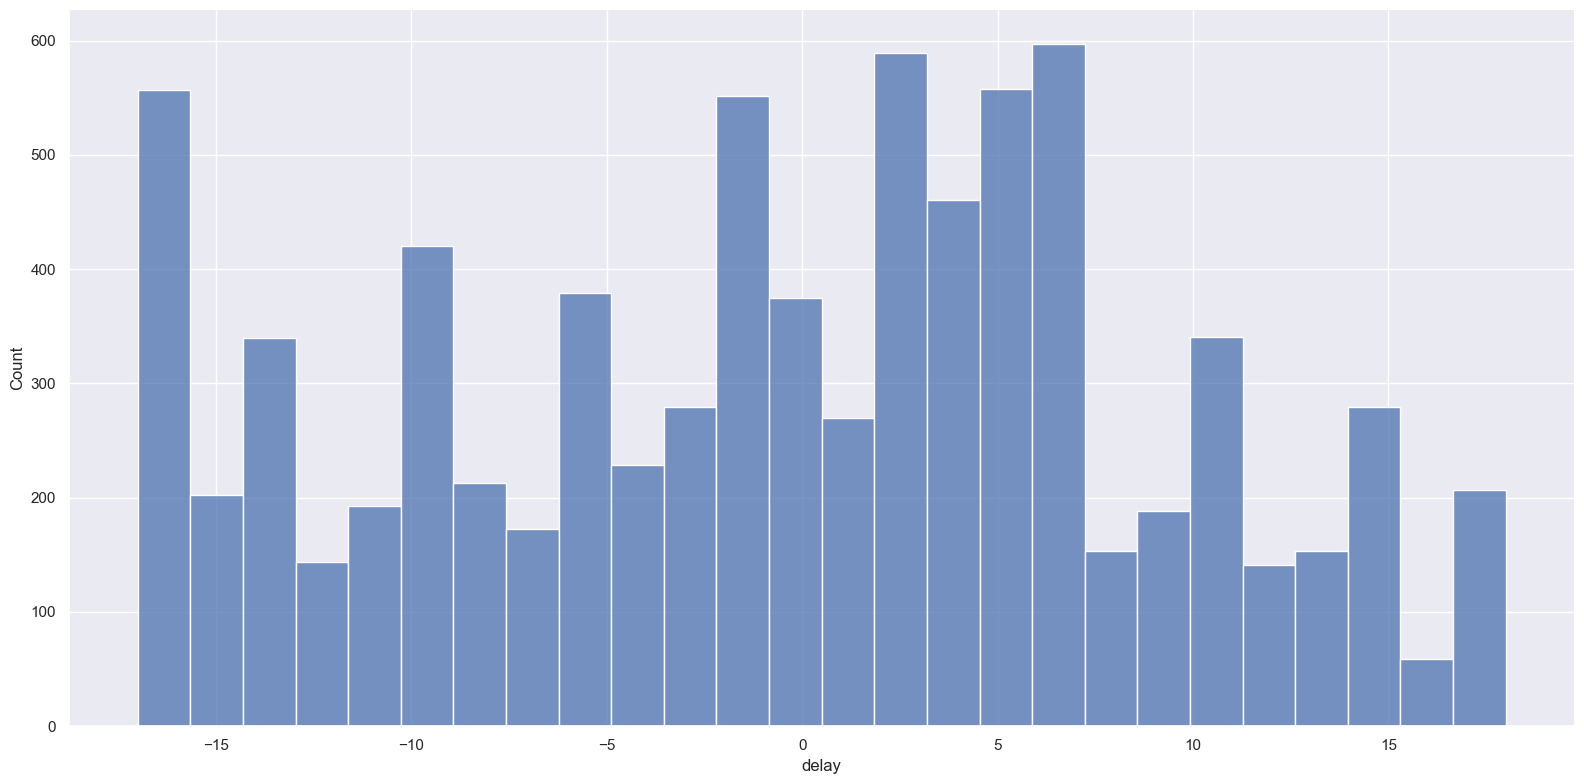

In [43]:
sns.set(rc={'figure.figsize':(10,10)}) 
sns.displot(df['delay'],aspect = 2,height=8)

In [44]:
df.groupby('payment terms')['payment terms'].count().sort_values(ascending=False).iloc[:30]

payment terms
Z071    2847
ZZ63    1767
Z513    1512
ZZ29     779
ZZ28     566
Z536     455
Z205     117
Z843       9
Name: payment terms, dtype: int64

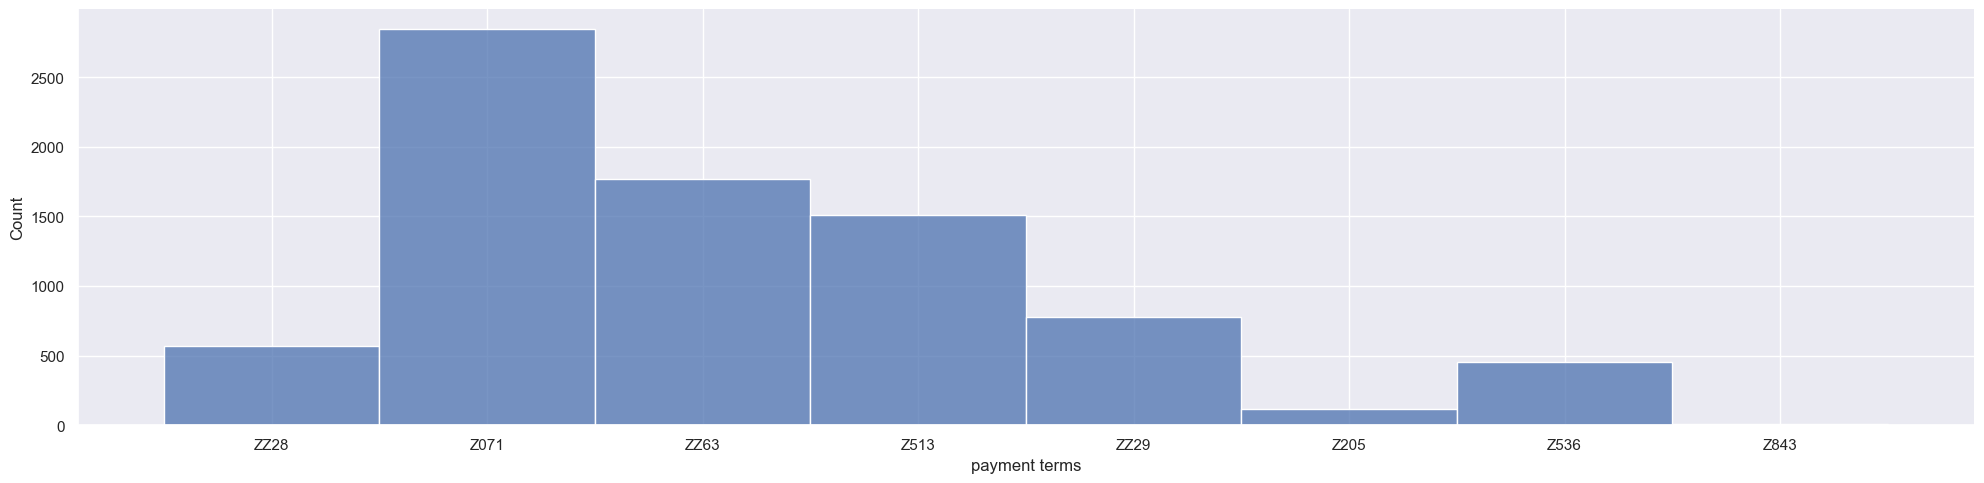

In [45]:
sns.displot(df[df['payment terms'].isin(['Z071','ZZ63','Z513','ZZ29','ZZ28','Z536','Z205','Z843'])]
            ['payment terms'],aspect = 4)

In [46]:
df.groupby(df['baseline_date_norm'].dt.year)['delay'].agg(['mean','median','count','min','max','std'])

,mean,median,count,min,max,std
baseline_date_norm,,,,,,
2019,1.033453,3.0,837,-17,18,8.611988
2020,-0.941733,0.0,4651,-17,18,9.173585
2021,0.124025,1.0,2564,-17,18,9.276070


In [47]:
df.groupby(df['baseline_date_norm'].dt.year)['amount'].agg(['mean','median','count','min','max','std'])

,mean,median,count,min,max,std
baseline_date_norm,,,,,,
2019,169466.335615,1184.22,837,2.26,21119319.57,1.421196e+06
2020,215503.599761,904.80,4651,2.26,59874861.44,1.850365e+06
2021,229993.865101,930.94,2564,2.01,46331921.30,2.007943e+06


In [48]:
df.groupby(df['baseline_date_norm'].dt.year)['payment terms'].agg(['count','nunique',pd.Series.mode])

,count,nunique,mode
baseline_date_norm,,,
2019,837,8,Z071
2020,4651,8,Z071
2021,2564,8,Z071


In [49]:
sns.set(rc={'figure.figsize':(20,10)}) 

<Axes: xlabel='mega_date', ylabel='delay'>

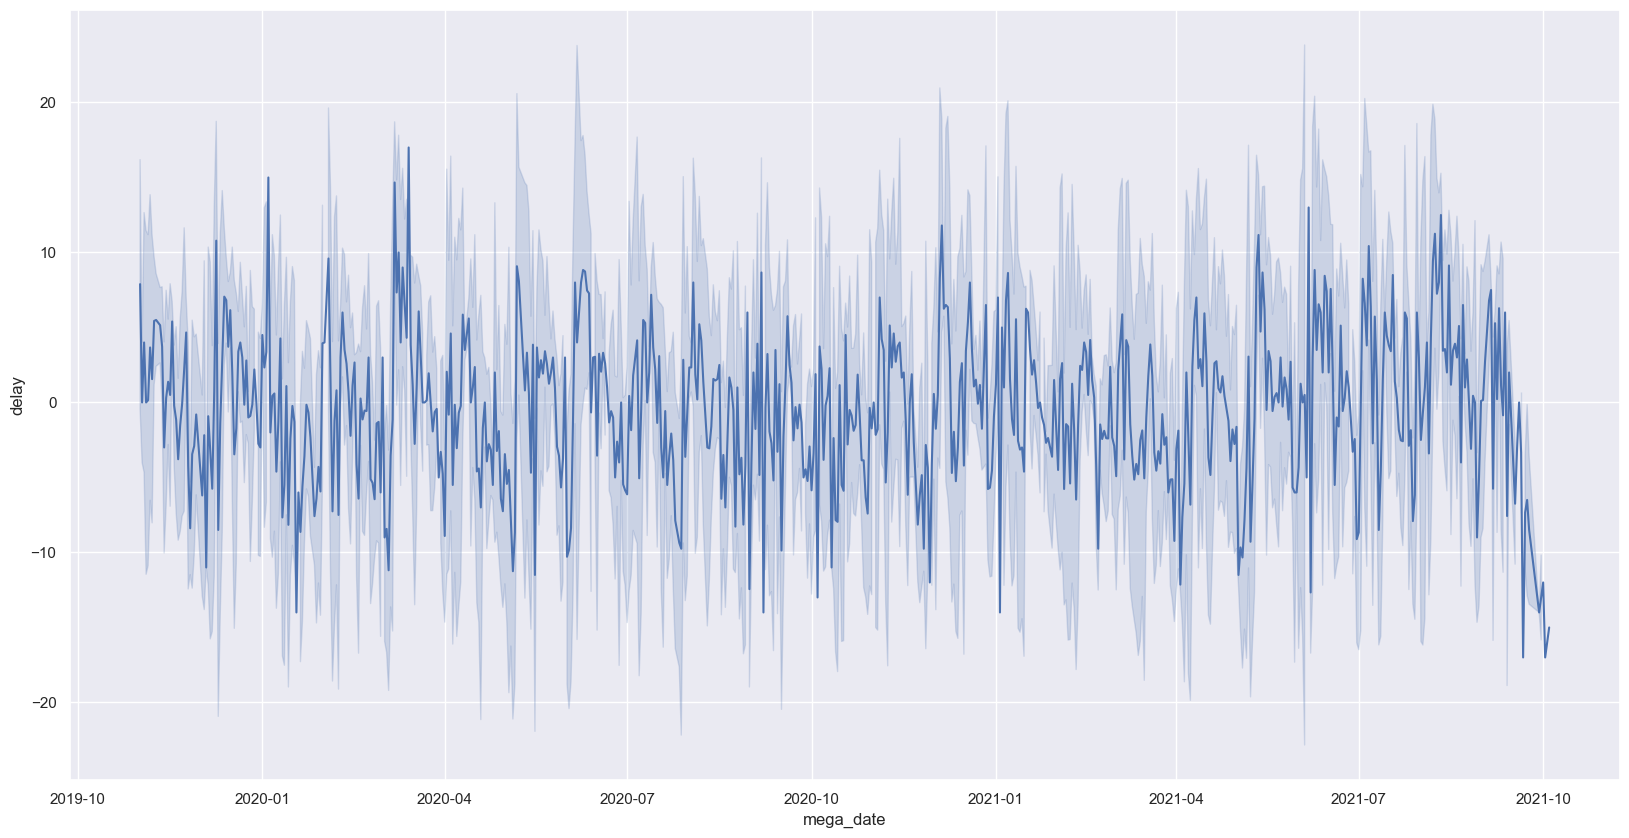

In [50]:
sns.lineplot(x=df['mega_date'],y=df['delay'],ci='sd')

<Axes: xlabel='mega_date', ylabel='delay'>

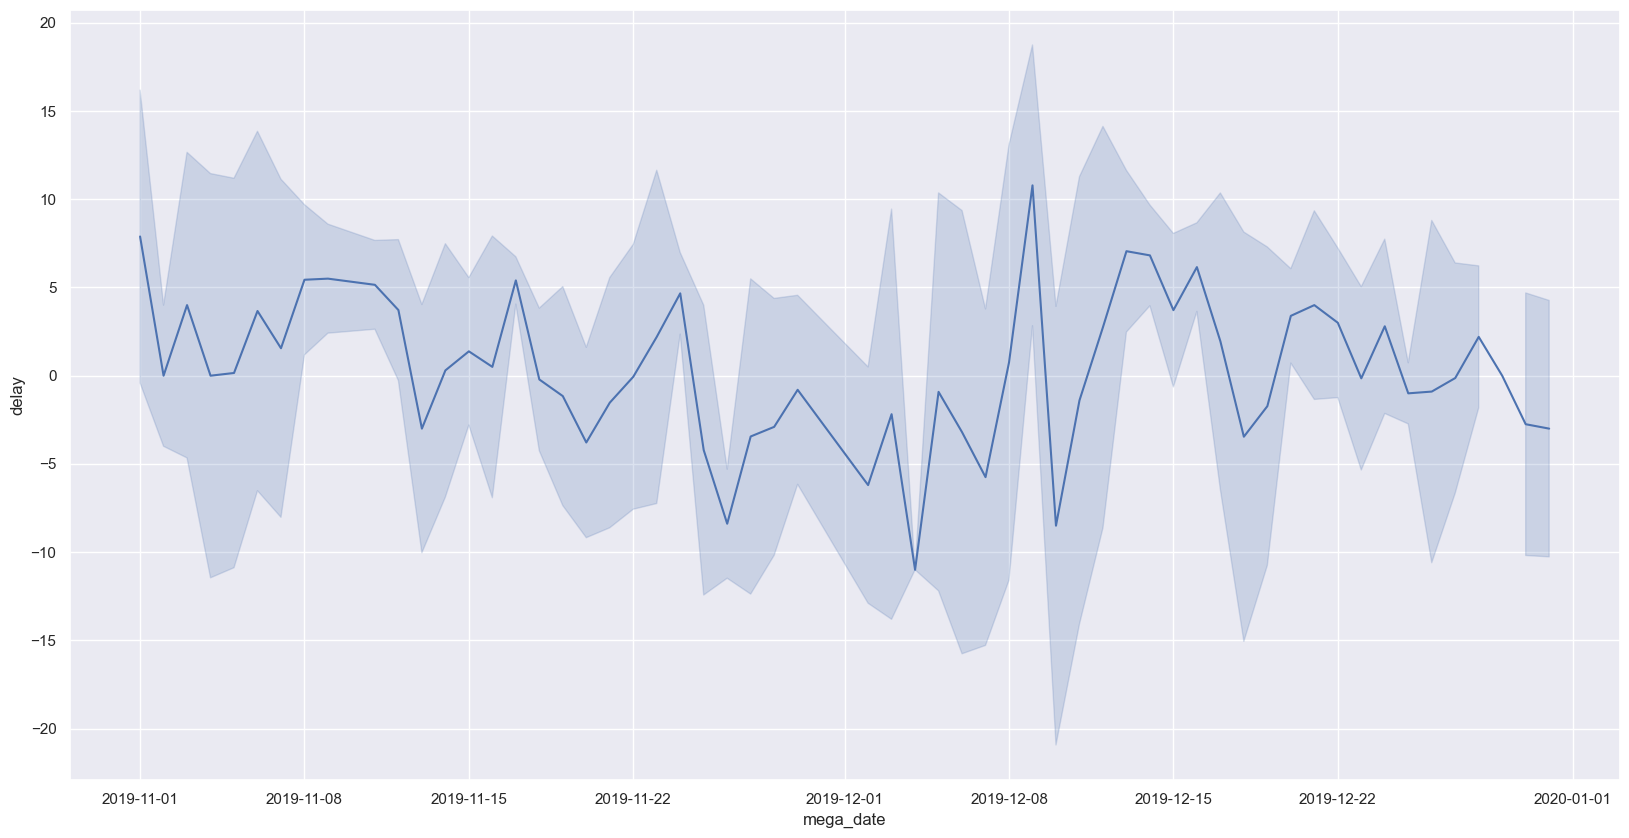

In [51]:
sns.lineplot(x=df[df['mega_date'].dt.year == 2019]['mega_date'],y=df[df['mega_date'].dt.year == 2019]['delay'],ci='sd')

<Axes: xlabel='mega_date', ylabel='delay'>

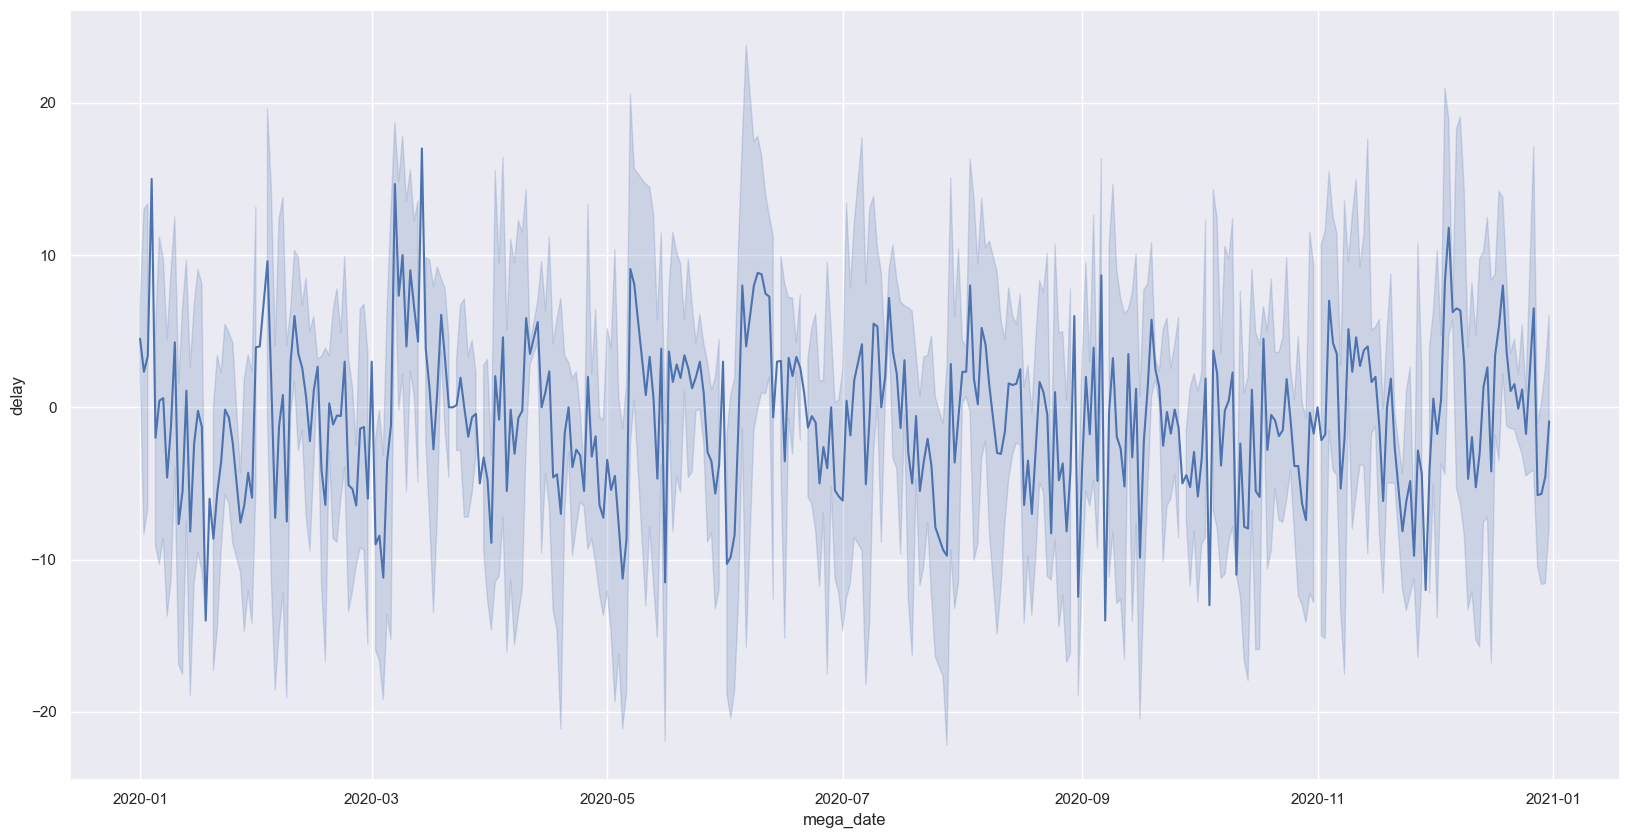

In [52]:
sns.lineplot(x=df[df['mega_date'].dt.year == 2020]['mega_date'],y=df[df['mega_date'].dt.year == 2020]['delay'],ci='sd')

<Axes: xlabel='mega_date', ylabel='delay'>

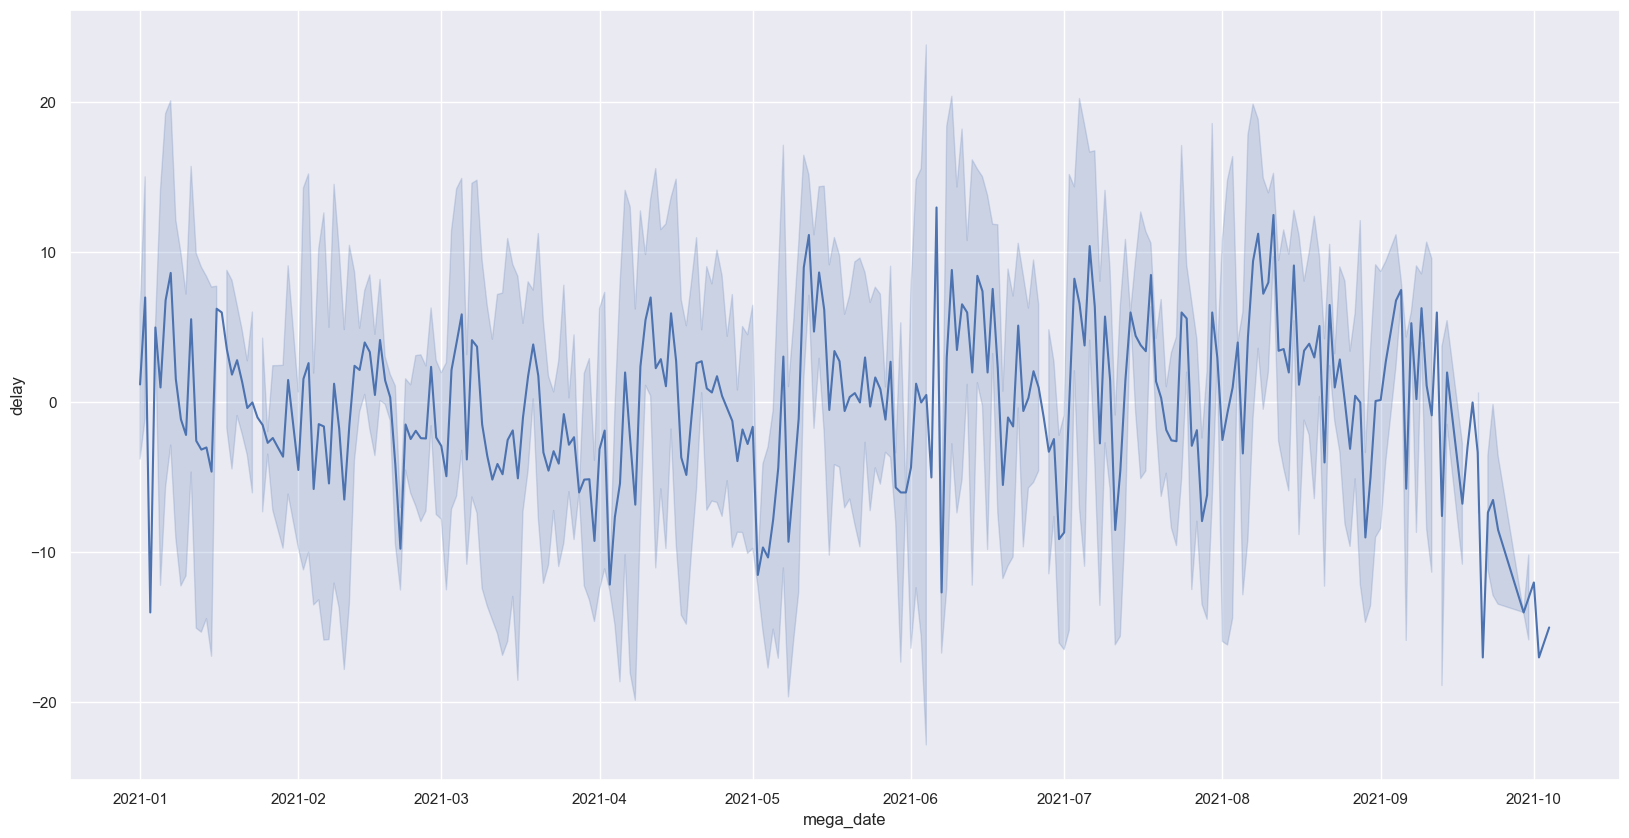

In [53]:
sns.lineplot(x=df[df['mega_date'].dt.year == 2021]['mega_date'],y=df[df['mega_date'].dt.year == 2021]['delay'],ci='sd')

In [54]:
df[df['baseline_date_norm'].dt.year == 2019].groupby('fk_customer_map_id')['amount'].sum().sort_values(ascending=False).head().index

Index([102923445, 103024047, 102865946, 102986756, 102906533], dtype='int64', name='fk_customer_map_id')

In [55]:
sns.set(rc={'figure.figsize':(10,6)}) 

<Axes: xlabel='week', ylabel='amount'>

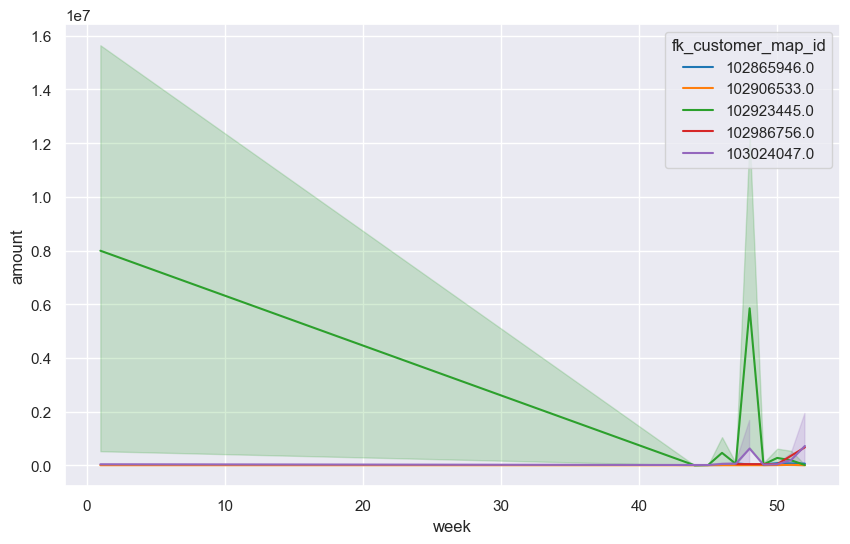

In [56]:
sns.lineplot(x = df.loc[(df['baseline_date_norm'].dt.year == 2019) & (df['fk_customer_map_id'].isin([102923445, 103024047, 102865946, 102986756, 102906533])),
                             'baseline_date_norm'].dt.isocalendar().week, y=df['amount'],
             hue=df.loc[df['fk_customer_map_id'].isin([102923445, 103024047, 102865946, 102986756, 102906533]),'fk_customer_map_id'],
             palette='tab10')

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8052 entries, 0 to 8051
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   cms_doc_header_id   8052 non-null   int64         
 1   fk_customer_map_id  8052 non-null   int64         
 2   amount              8052 non-null   float64       
 3   due_date            8052 non-null   datetime64[ns]
 4   clearing_date       8052 non-null   datetime64[ns]
 5   create_date         8052 non-null   datetime64[ns]
 6   baseline_date_norm  8052 non-null   datetime64[ns]
 7   mega_date           8052 non-null   datetime64[ns]
 8   payment terms       8052 non-null   object        
 9   payment mode        8052 non-null   object        
 10  delay               8052 non-null   int64         
 11  payment_time        8052 non-null   int64         
 12  delay_bucket        8052 non-null   object        
dtypes: datetime64[ns](5), float64(1), int64(4), obje

## Customer segment wise delay patterns

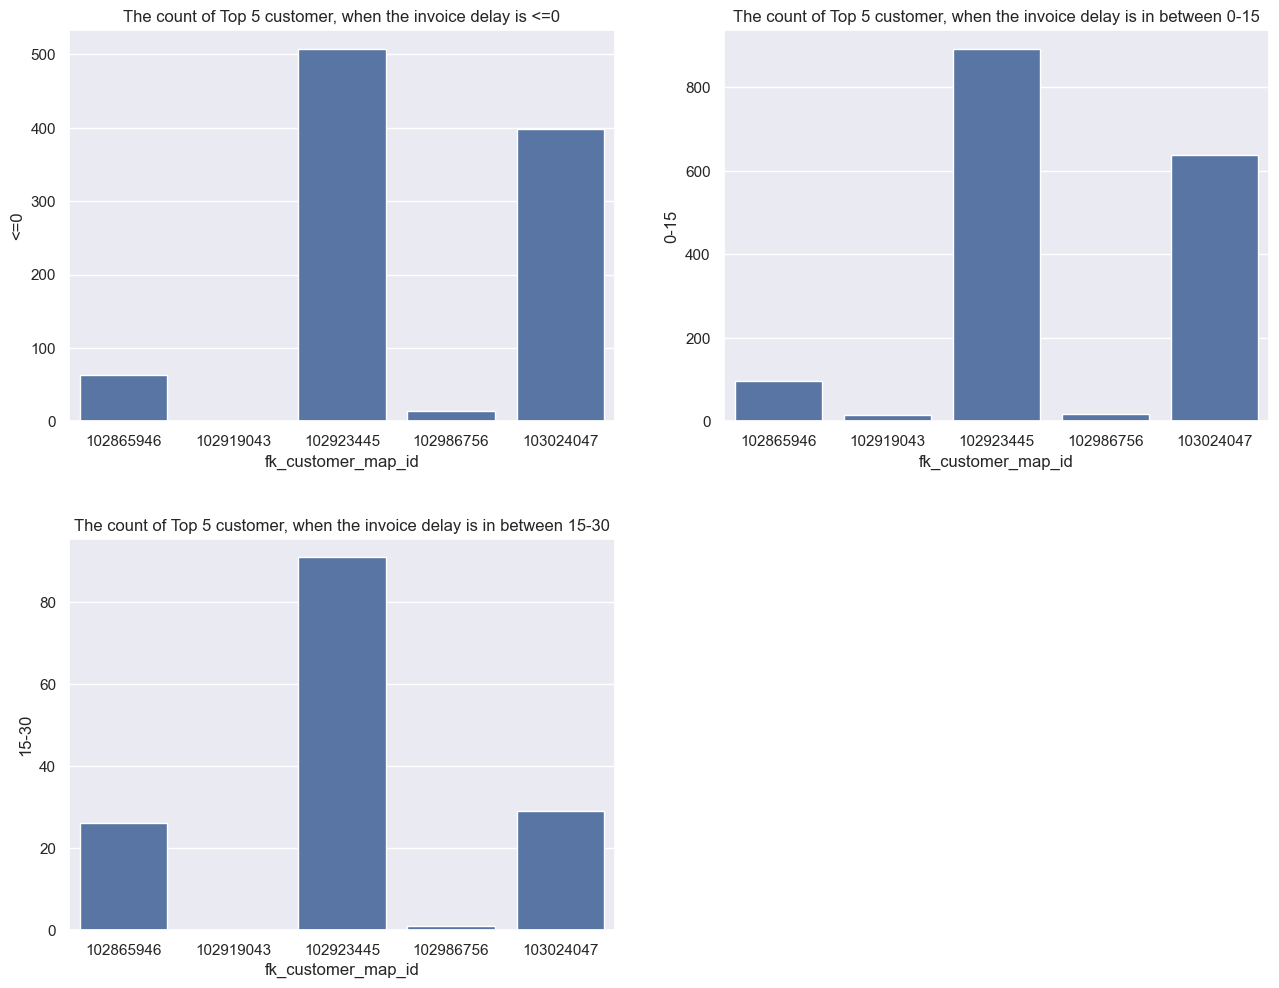

                      Top 5 customers & their delay pattern on the basis of Total amount contribution   


In [58]:
#Total Amount contribution

df_eda = df.groupby(["fk_customer_map_id"])["amount"].sum().sort_values(ascending=False).head(5).reset_index()
some_values = df_eda.fk_customer_map_id
df_eda = df.loc[df['fk_customer_map_id'].isin(some_values)]
df_eda = df_eda.groupby(["fk_customer_map_id"])["delay_bucket"].value_counts().unstack().reset_index()

#  SUBPLOTS - 2x2
fig = plt.figure(figsize=(15,10))

#----------------------------------------------------------------------------------------------------------------
plt.subplot(221)   #  subplot 1
plt.title('The count of Top 5 customer, when the invoice delay is <=0')
sns.barplot(x='fk_customer_map_id', y='<=0',data=df_eda)
#----------------------------------------------------------------------------------------------------------------
plt.subplot(222)   #  subplot 2
plt.title('The count of Top 5 customer, when the invoice delay is in between 0-15')
sns.barplot(x='fk_customer_map_id', y='0-15',data=df_eda)
#----------------------------------------------------------------------------------------------------------------
plt.subplot(223)   #  subplot 3 
plt.title('The count of Top 5 customer, when the invoice delay is in between 15-30')
sns.barplot(x='fk_customer_map_id', y='15-30',data=df_eda)
#----------------------------------------------------------------------------------------------------------------
# plt.subplot(224)   #  subplot 4 
# plt.title('The count of Top 5 customer, when the invoice delay is in between >30')
# sns.barplot(x='CUSTOMER_NUMBER', y='>30',data=df_eda)
#----------------------------------------------------------------------------------------------------------------
plt.subplots_adjust(left=0.1,
                    bottom=.1, 
                    right=0.9, 
                    top=1.0, 
                    wspace=0.2, 
                    hspace=0.3)
plt.show()

print('                      Top 5 customers & their delay pattern on the basis of Total amount contribution   ')

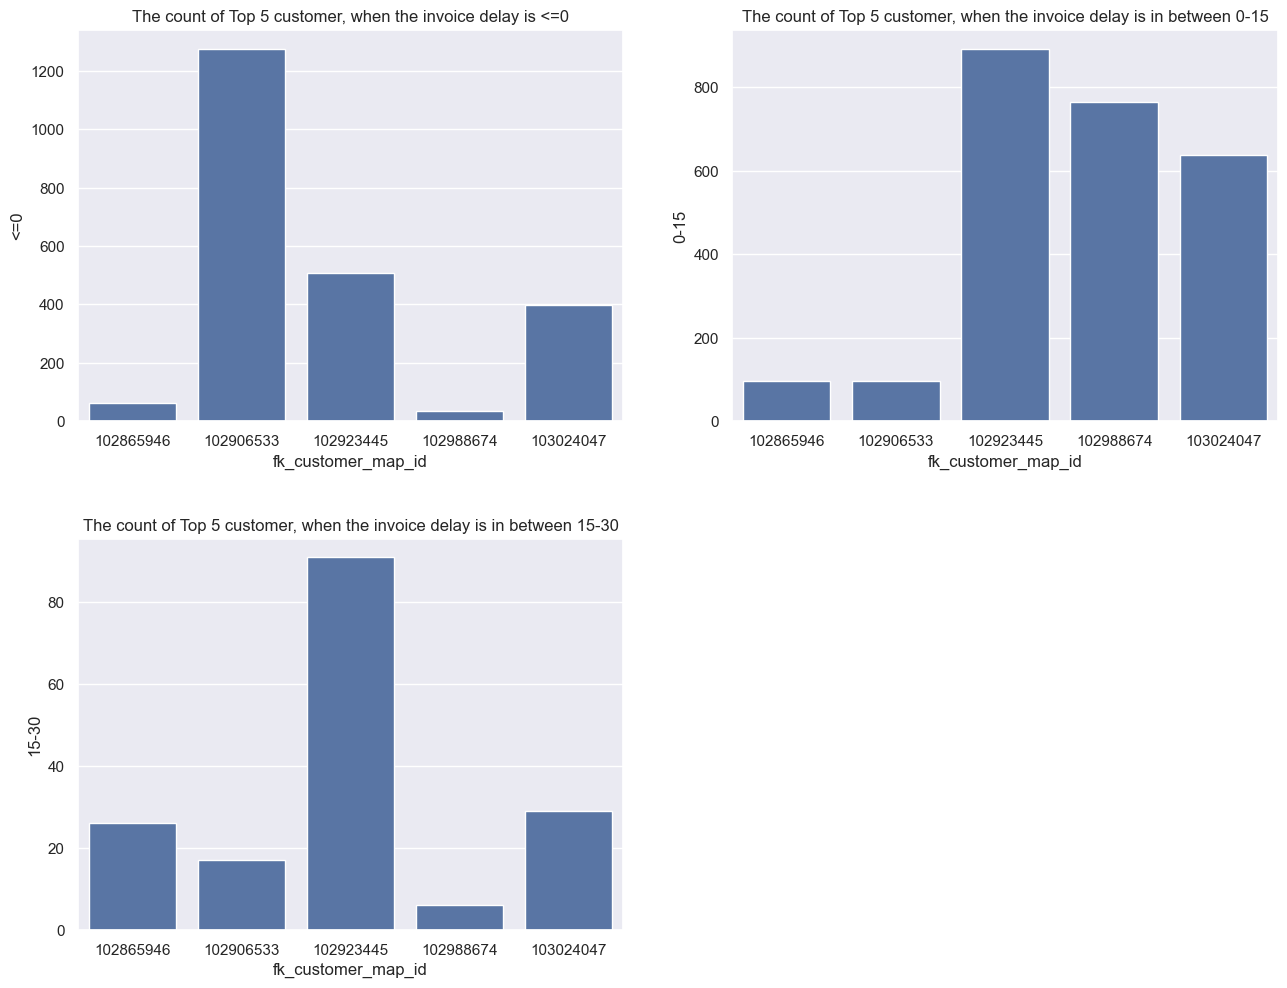

                      Top 5 customers & their delay pattern on the basis of Total Invoice contribution   


In [59]:
#Total Invoice contribution

df_eda = df.groupby(["fk_customer_map_id"])["amount"].count().sort_values(ascending=False).head(5).reset_index()
some_values = df_eda.fk_customer_map_id
df_eda = df.loc[df['fk_customer_map_id'].isin(some_values)]
df_eda = df_eda.groupby(["fk_customer_map_id"])["delay_bucket"].value_counts().unstack().reset_index()
#----------------------------------------------------------------------------------------------------------------
#  SUBPLOTS - 2x2
fig = plt.figure(figsize=(15,10))

#----------------------------------------------------------------------------------------------------------------
plt.subplot(221)   #  subplot 1
plt.title('The count of Top 5 customer, when the invoice delay is <=0')
sns.barplot(x='fk_customer_map_id', y='<=0',data=df_eda)
#----------------------------------------------------------------------------------------------------------------
plt.subplot(222)   #  subplot 2
plt.title('The count of Top 5 customer, when the invoice delay is in between 0-15')
sns.barplot(x='fk_customer_map_id', y='0-15',data=df_eda)
#----------------------------------------------------------------------------------------------------------------
plt.subplot(223)   #  subplot 3 
plt.title('The count of Top 5 customer, when the invoice delay is in between 15-30')
sns.barplot(x='fk_customer_map_id', y='15-30',data=df_eda)
#----------------------------------------------------------------------------------------------------------------
# plt.subplot(224)   #  subplot 4 
# plt.title('The count of Top 5 customer, when the invoice delay is in between >30')
# sns.barplot(x='CUSTOMER_NUMBER', y='>30',data=df_eda)
#----------------------------------------------------------------------------------------------------------------
plt.subplots_adjust(left=0.1,
                    bottom=.1, 
                    right=0.9, 
                    top=1.0, 
                    wspace=0.2, 
                    hspace=0.3)
plt.show()
print('                      Top 5 customers & their delay pattern on the basis of Total Invoice contribution   ')

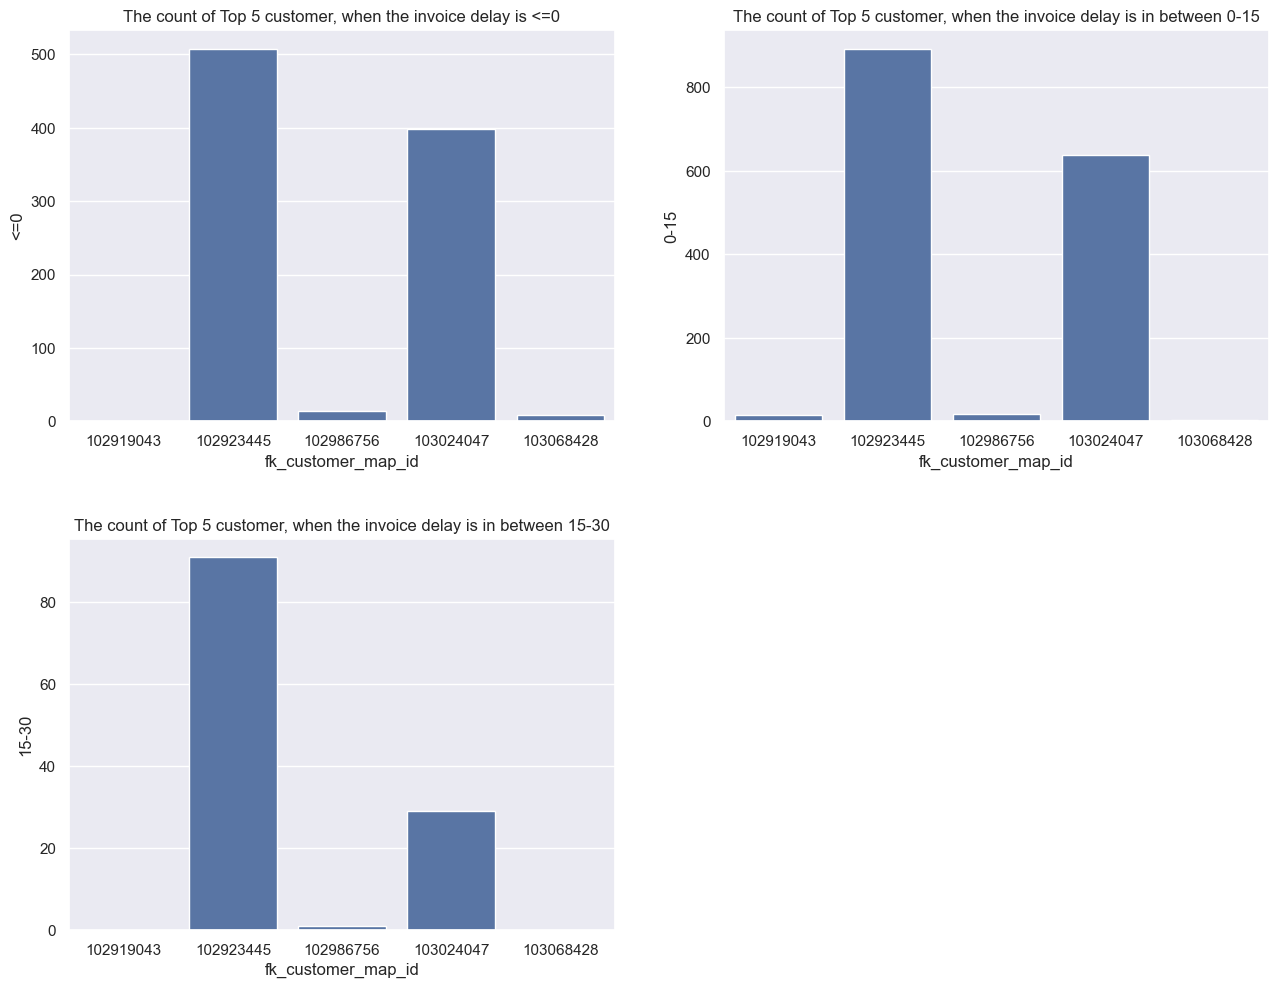

                      Top 5 customers & their delay pattern on the basis of Average Amount contribution   


In [60]:
#Average Amount contribution

df_eda = df.groupby(["fk_customer_map_id"])["amount"].mean().sort_values(ascending=False).head(5).reset_index()
some_values = df_eda.fk_customer_map_id
df_eda = df.loc[df['fk_customer_map_id'].isin(some_values)]
df_eda = df_eda.groupby(["fk_customer_map_id"])["delay_bucket"].value_counts().unstack().reset_index()
#----------------------------------------------------------------------------------------------------------------
#  SUBPLOTS - 2x2
fig = plt.figure(figsize=(15,10))

#----------------------------------------------------------------------------------------------------------------
plt.subplot(221)   #  subplot 1
plt.title('The count of Top 5 customer, when the invoice delay is <=0')
sns.barplot(x='fk_customer_map_id', y='<=0',data=df_eda)
#----------------------------------------------------------------------------------------------------------------
plt.subplot(222)   #  subplot 2
plt.title('The count of Top 5 customer, when the invoice delay is in between 0-15')
sns.barplot(x='fk_customer_map_id', y='0-15',data=df_eda)
#----------------------------------------------------------------------------------------------------------------
plt.subplot(223)   #  subplot 3 
plt.title('The count of Top 5 customer, when the invoice delay is in between 15-30')
sns.barplot(x='fk_customer_map_id', y='15-30',data=df_eda)
#----------------------------------------------------------------------------------------------------------------
# plt.subplot(224)   #  subplot 4 
# plt.title('The count of Top 5 customer, when the invoice delay is in between >30')
# sns.barplot(x='CUSTOMER_NUMBER', y='>30',data=df_eda)
#----------------------------------------------------------------------------------------------------------------
plt.subplots_adjust(left=0.1,
                    bottom=.1, 
                    right=0.9, 
                    top=1.0, 
                    wspace=0.2, 
                    hspace=0.3)
plt.show()

print('                      Top 5 customers & their delay pattern on the basis of Average Amount contribution   ')

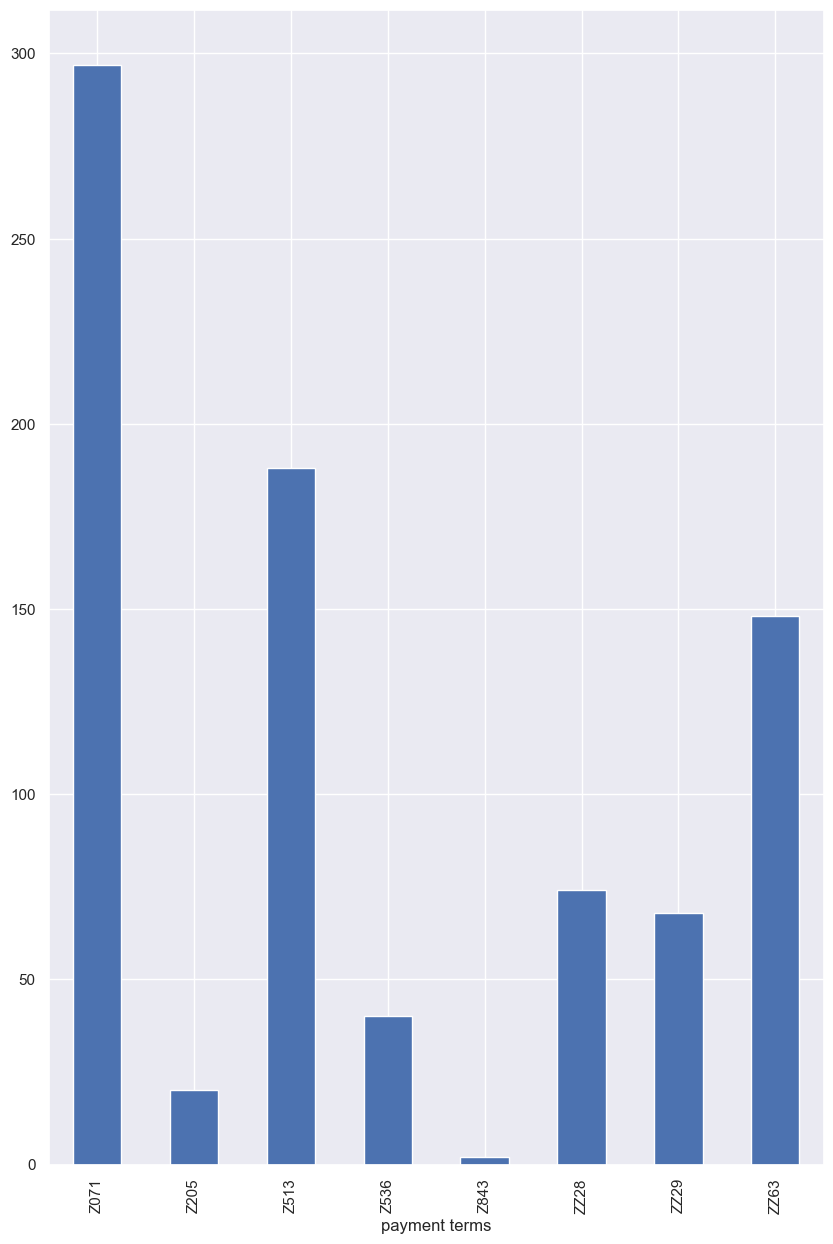

In [61]:
plt.figure(figsize = (10,15))
df[df['baseline_date_norm'].dt.year == 2019].groupby('payment terms')['payment terms'].count().plot.bar()
plt.show()

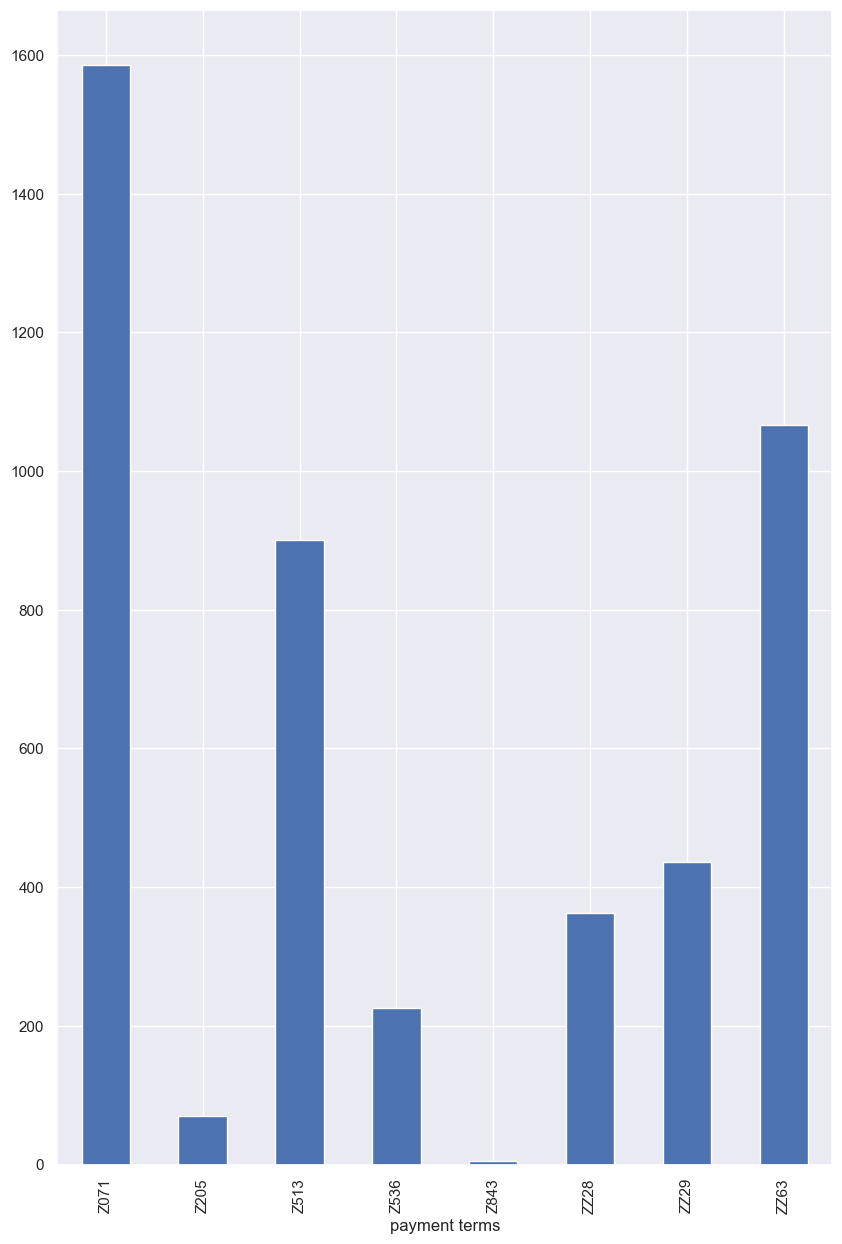

In [62]:
plt.figure(figsize = (10,15))
df[df['baseline_date_norm'].dt.year==2020].groupby('payment terms')['payment terms'].count().plot.bar()
plt.show()

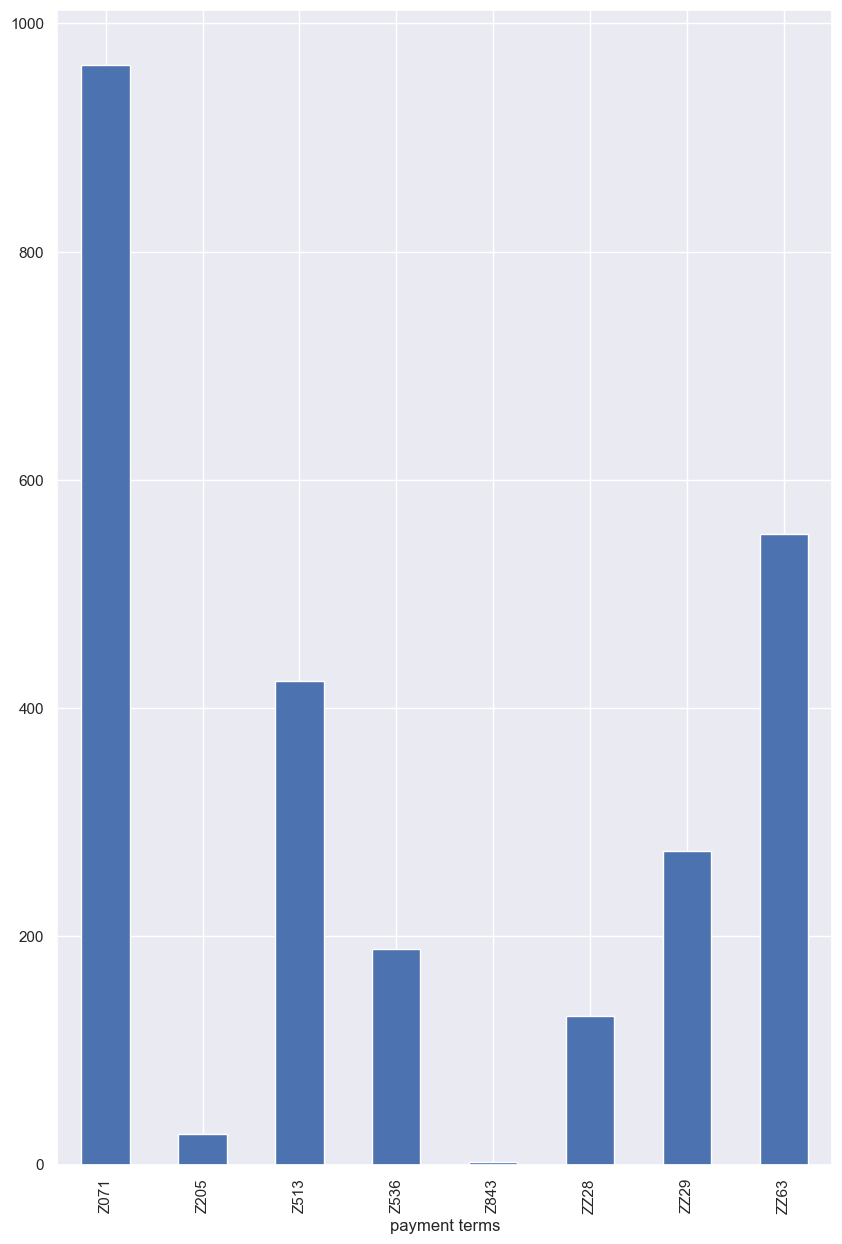

In [63]:
plt.figure(figsize = (10,15))
df[df['baseline_date_norm'].dt.year==2021].groupby('payment terms')['payment terms'].count().plot.bar()
plt.show()

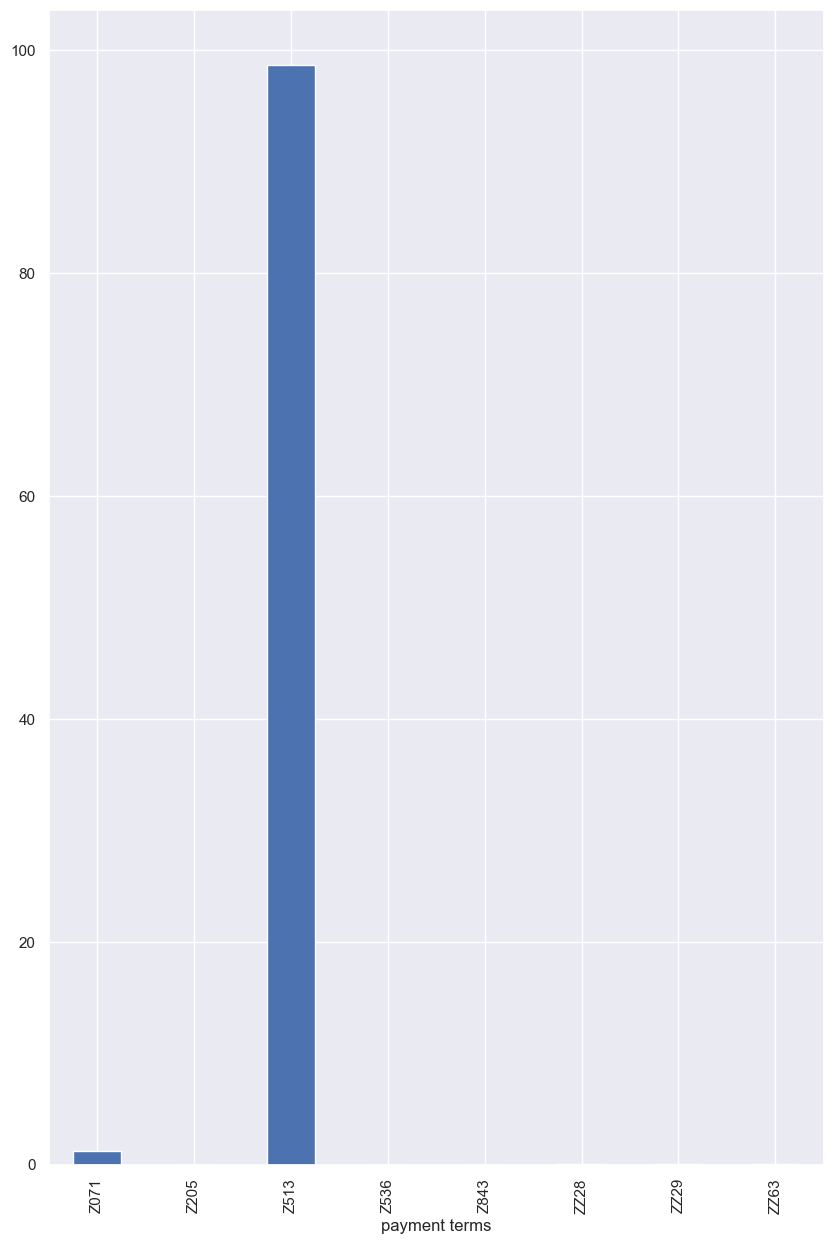

In [64]:
invoice=df[df['baseline_date_norm'].dt.year==2019].groupby('payment terms')['amount'].sum()
invoice['contri']=invoice.apply( lambda x: x/sum(invoice)*100)
invoice_contri=pd.DataFrame(invoice['contri'])
invoice_contri = invoice_contri.rename(columns= {'amount': '%contri',0:'payment terms'})
invoice_contri.reset_index
plt.figure(figsize = (10,15))
invoice_contri['%contri'].plot.bar()
plt.show()

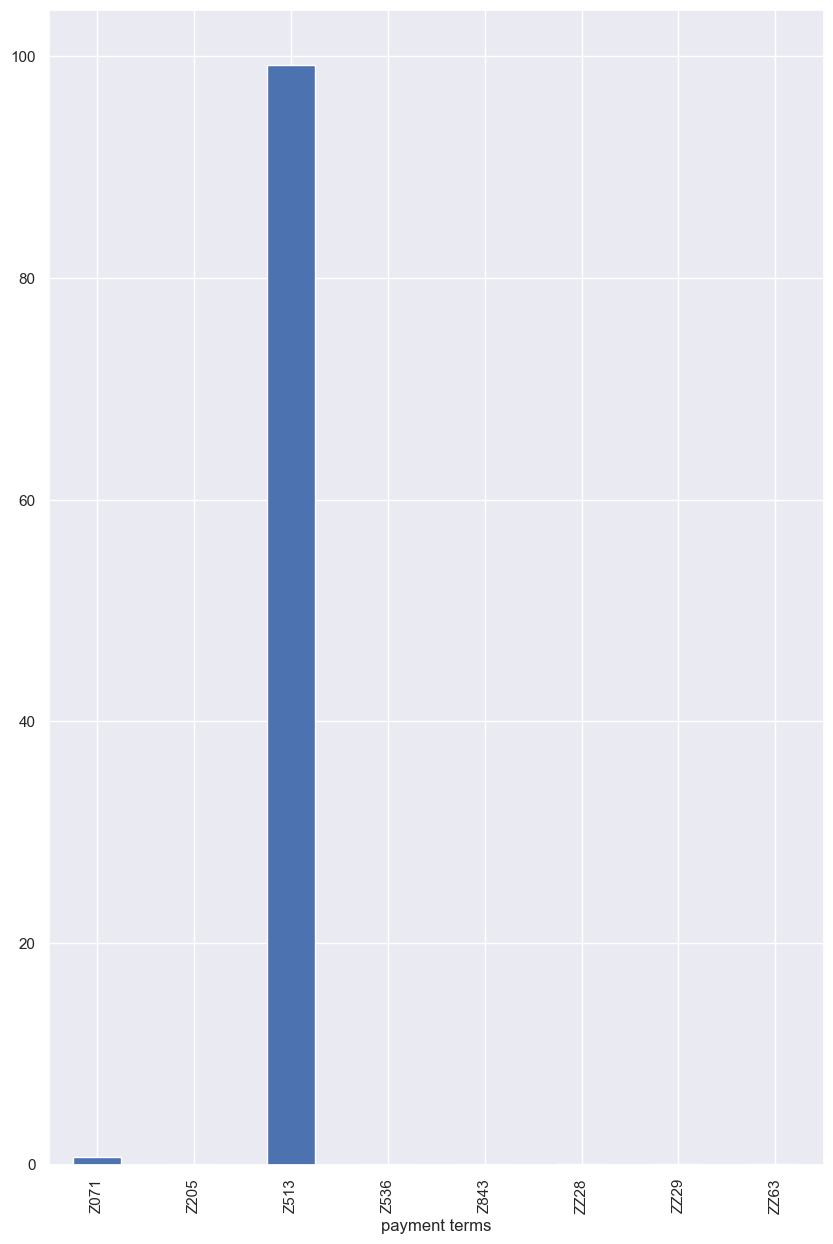

In [65]:
invoice=df[df['baseline_date_norm'].dt.year==2020].groupby('payment terms')['amount'].sum()
invoice['contri']=invoice.apply( lambda x: x/sum(invoice)*100)
invoice_contri=pd.DataFrame(invoice['contri'])
invoice_contri = invoice_contri.rename(columns= {'amount': '%contri',0:'payment terms'})
invoice_contri.reset_index
plt.figure(figsize = (10,15))
invoice_contri['%contri'].plot.bar()
plt.show()

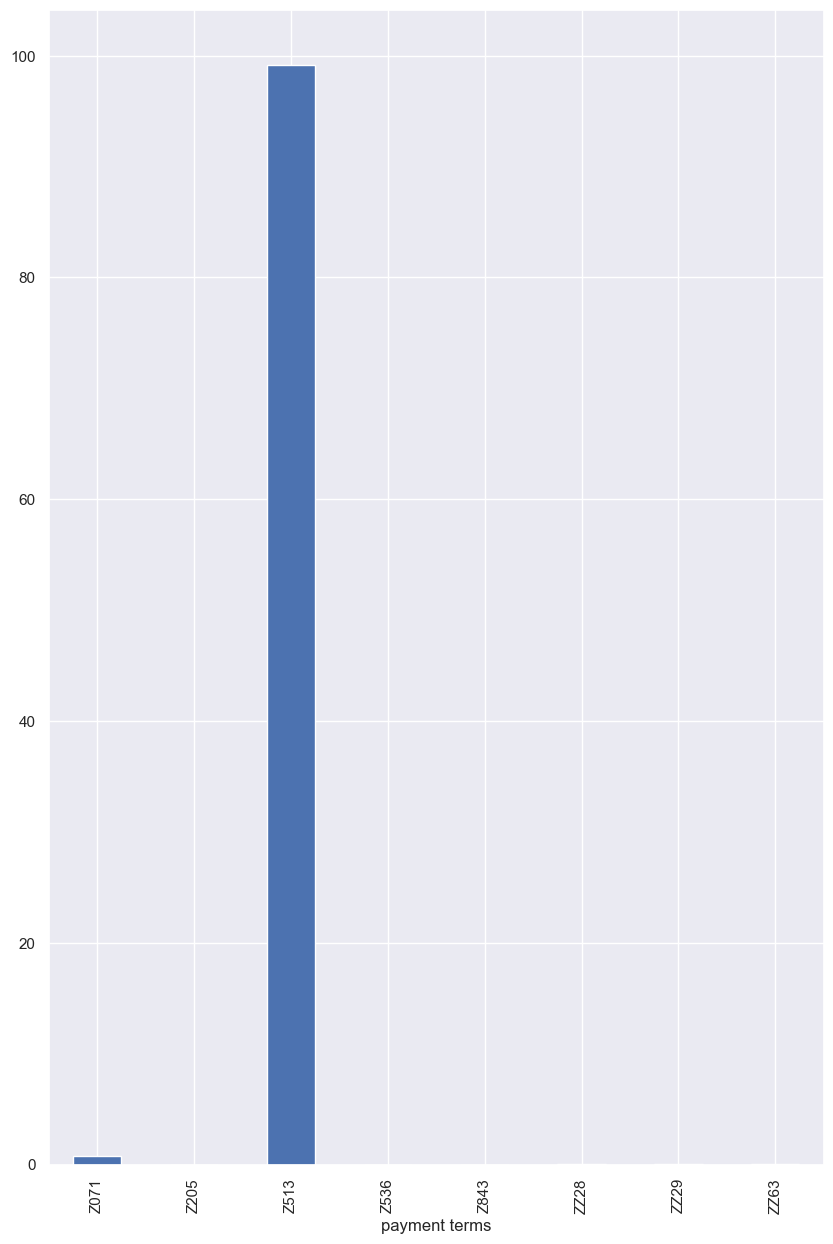

In [66]:
invoice=df[df['baseline_date_norm'].dt.year==2021].groupby('payment terms')['amount'].sum()
invoice['contri']=invoice.apply( lambda x: x/sum(invoice)*100)
invoice_contri=pd.DataFrame(invoice['contri'])
invoice_contri = invoice_contri.rename(columns= {'amount': '%contri',0:'payment terms'})
invoice_contri.reset_index
plt.figure(figsize = (10,15))
invoice_contri['%contri'].plot.bar()
plt.show()

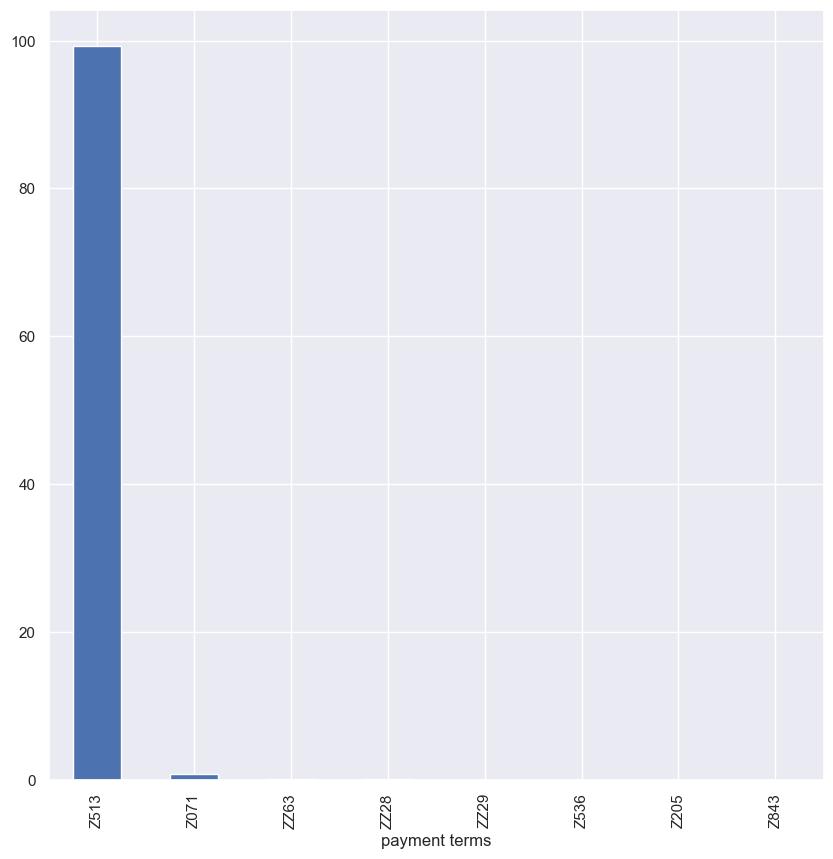

In [67]:
invoice=df[df['baseline_date_norm'].dt.year==2020].groupby('payment terms')['amount'].sum().sort_values(ascending=False).head(10)
invoice['contri']=invoice.apply( lambda x: x/sum(invoice)*100)
invoice_contri=pd.DataFrame(invoice['contri'])
invoice_contri = invoice_contri.rename(columns= {'amount': '%contri',0:'payment terms'})
invoice_contri.reset_index
plt.figure(figsize = (10,10))
invoice_contri['%contri'].plot.bar()
plt.show()

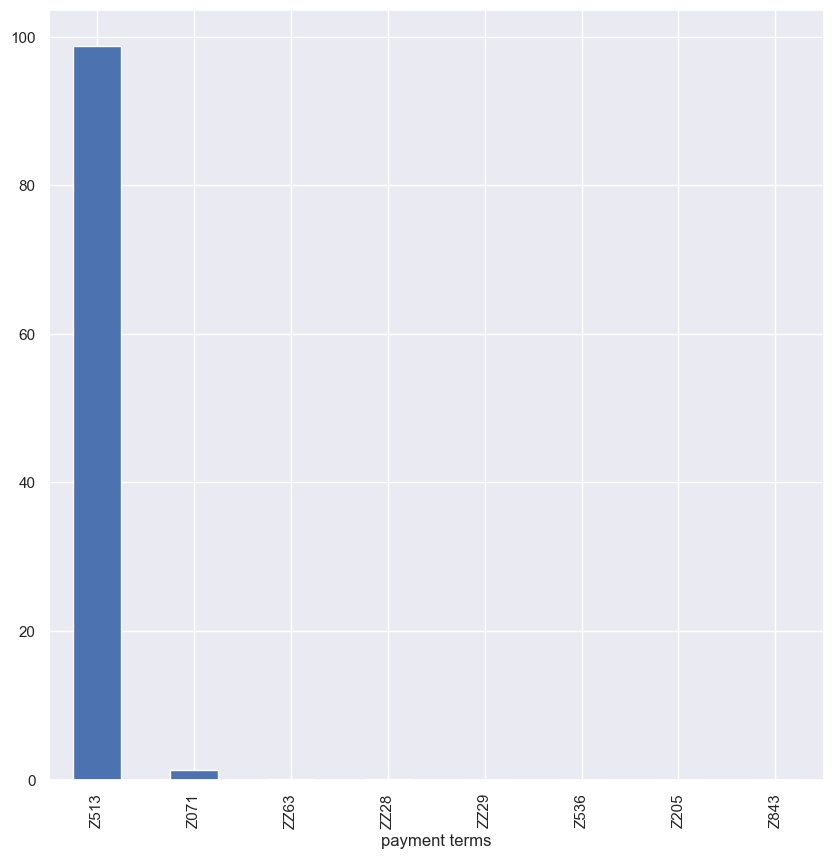

In [68]:
invoice=df[df['baseline_date_norm'].dt.year==2019].groupby('payment terms')['amount'].sum().sort_values(ascending=False).head(10)
invoice['contri']=invoice.apply( lambda x: x/sum(invoice)*100)
invoice_contri=pd.DataFrame(invoice['contri'])
invoice_contri = invoice_contri.rename(columns= {'amount': '%contri',0:'payment terms'})
invoice_contri.reset_index
plt.figure(figsize = (10,10))
invoice_contri['%contri'].plot.bar()
plt.show()

['cms_doc_header_id', 'fk_customer_map_id', 'amount', 'delay', 'payment_time']


<Axes: >

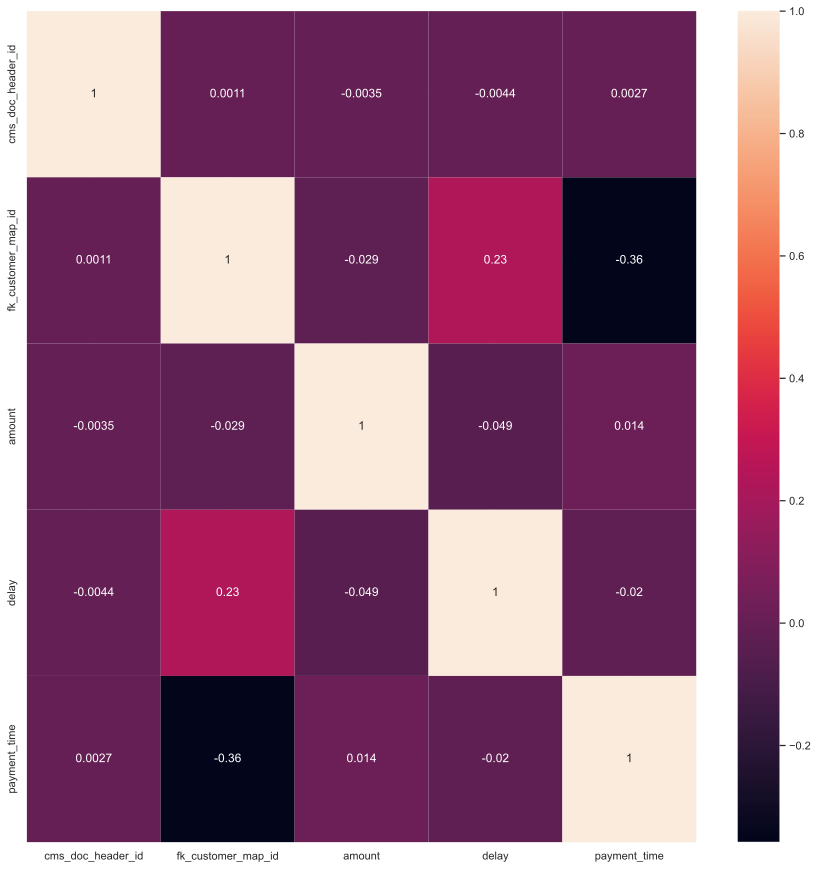

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'svg'
numerical_columns=df.select_dtypes(include=np.number).columns.tolist()
print(numerical_columns)
numerical =df.select_dtypes(include=np.number)
correlation=numerical.corr()
plt.figure(figsize = (15,15))
sns.heatmap(correlation,annot=True)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8052 entries, 0 to 8051
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   cms_doc_header_id   8052 non-null   int64         
 1   fk_customer_map_id  8052 non-null   int64         
 2   amount              8052 non-null   float64       
 3   due_date            8052 non-null   datetime64[ns]
 4   clearing_date       8052 non-null   datetime64[ns]
 5   create_date         8052 non-null   datetime64[ns]
 6   baseline_date_norm  8052 non-null   datetime64[ns]
 7   mega_date           8052 non-null   datetime64[ns]
 8   payment terms       8052 non-null   object        
 9   payment mode        8052 non-null   object        
 10  delay               8052 non-null   int64         
 11  payment_time        8052 non-null   int64         
 12  delay_bucket        8052 non-null   object        
dtypes: datetime64[ns](5), float64(1), int64(4), obje

In [71]:
df.shape

(8052, 13)

## Outliers in the data

In [72]:
dataframe = df.copy()
def find_skewed_boundaries(df, variable, distance):
    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)
    lower_boundary = df[variable].quantile(0.25) - (IQR * distance)
    upper_boundary = df[variable].quantile(0.75) + (IQR * distance)
    return upper_boundary, lower_boundary
upper_delay,lower_delay = find_skewed_boundaries(dataframe,'delay',3)
upper_amount,lower_amount = find_skewed_boundaries(dataframe,'amount',3)
print('Delay Capping are',lower_delay,upper_delay)
print('Amount Capping are',lower_amount,upper_amount)
print("If capping happens on delay",dataframe[dataframe.delay.between(lower_delay,upper_delay)].shape,"% of records =",1-dataframe[dataframe.delay.between(lower_delay,upper_delay)].shape[0]/dataframe.shape[0])
print("If capping happens on delay",dataframe[dataframe.delay.between(lower_delay,upper_delay)].shape)
print("If capping happens on amount",dataframe[dataframe.amount.between(lower_amount,upper_amount)].shape,"% of records =",1-dataframe[dataframe.amount.between(lower_amount,upper_amount)].shape[0]/dataframe.shape[0])
print("If capping happens on amount",dataframe[dataframe.amount.between(lower_amount,upper_amount)].shape)


Delay Capping are -50.0 48.0
Amount Capping are -26683.12 36181.815
If capping happens on delay (8052, 13) % of records = 0.0
If capping happens on delay (8052, 13)
If capping happens on amount (6985, 13) % of records = 0.13251366120218577
If capping happens on amount (6985, 13)


Text(0.5, 1.0, 'Invoice contribution by the Top 30 Customers')

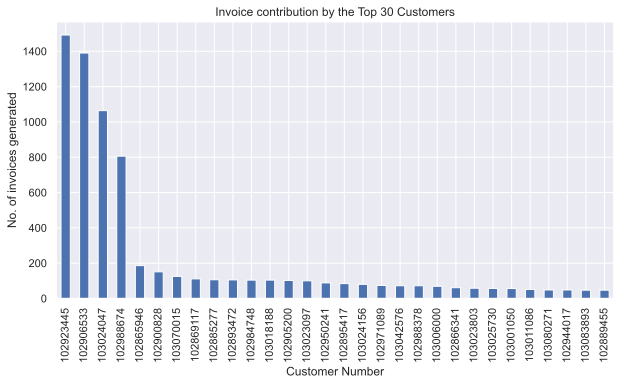

In [73]:
plt.subplots(figsize=(10,5))
(dataframe.groupby('fk_customer_map_id')['amount'].count().sort_values(ascending=False).head(30)).plot(kind='bar')
plt.xlabel('Customer Number')
plt.ylabel('No. of invoices generated')
plt.title('Invoice contribution by the Top 30 Customers')

Text(0.5, 1.0, 'Amount contribution by the Top 5 Customers')

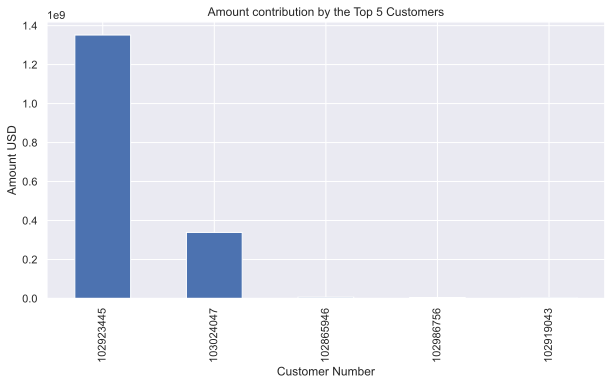

In [74]:
plt.subplots(figsize=(10,5))
(dataframe.groupby('fk_customer_map_id')['amount'].sum().sort_values(ascending=False).head(5)).plot(kind='bar')
plt.xlabel('Customer Number')
plt.ylabel('Amount USD')
plt.title('Amount contribution by the Top 5 Customers')

In [75]:
dataframe['Mega_month']=dataframe['mega_date'].dt.month
dataframe['Mega_year']=dataframe['mega_date'].dt.year
103024047
(dataframe[dataframe.fk_customer_map_id==102923445]).groupby(['Mega_year','Mega_month'])['delay'].mean()

Mega_year  Mega_month
2019       11            2.047619
           12            4.909091
2020       1             2.443038
           2             3.382022
           3             5.845070
           4             4.410714
           5             6.456522
           6             3.705882
           7             3.210526
           8            -1.187500
           9             4.641026
           10            3.546667
           11            1.931507
           12            4.626506
2021       1             4.272727
           2             3.125000
           3             3.783784
           4             5.833333
           5             6.333333
           6             7.982456
           7             3.707692
           8             6.126984
           9            -4.000000
Name: delay, dtype: float64

In [76]:
dataframe['Mega_month']=dataframe['mega_date'].dt.month
dataframe['Mega_year']=dataframe['mega_date'].dt.year

(dataframe[dataframe.fk_customer_map_id==103024047]).groupby(['Mega_year','Mega_month'])['delay'].mean()

Mega_year  Mega_month
2019       11             2.043956
           12             8.886598
2020       1              3.912500
           2              3.175439
           3              3.767857
           4              0.661017
           5              5.170213
           6              3.457627
           7              3.298246
           8             -2.750000
           9              2.887097
           10             0.687500
           11             1.754717
           12             2.436620
2021       1              4.084615
           2              2.650000
           3              9.000000
           5             -6.000000
           6            -11.000000
           9              7.000000
Name: delay, dtype: float64

## Before Outlier Removal

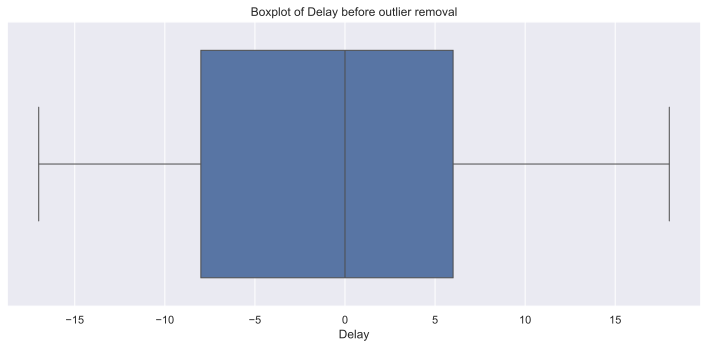

In [77]:
#plotting a boxplot of delay to see outlier values
plt.figure(figsize=(10,5))
sns.boxplot(x=df.delay, whis=3)
plt.title('Boxplot of Delay before outlier removal')
plt.xlabel('Delay')
plt.tight_layout()
plt.show()

<Figure size 800x800 with 0 Axes>

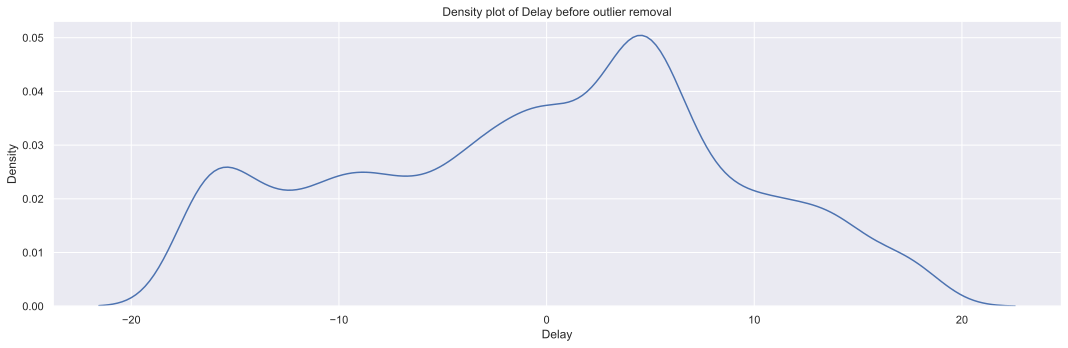

In [78]:
#plotting density plot of delay to see distribution
plt.figure(figsize=(8,8))
sns.displot(df.delay, kind='kde', aspect=3)
plt.title('Density plot of Delay before outlier removal')
plt.xlabel('Delay')
plt.tight_layout()
plt.show()

In [79]:
#we need to do outlier removal using IQR
#making a function to remove outliers
def outlier_fences(df, col_name):
    q1 = df[col_name].quantile(0.25)
    q3 = df[col_name].quantile(0.75)
    iqr = q3-q1 #Interquartile range
    fence_low  = q1-(iqr*3)
    fence_high = q3+(iqr*3)
    #df_out = df.loc[(df[col_name] > fence_low) & (df[col_name] < fence_high)]
    return fence_high, fence_low
upper_fence_delay, lower_fence_delay = outlier_fences(df,'delay')
upper_fence_amount,lower_fence_amount = outlier_fences(df,'amount')

#display upper and lower bounds for both variables
print('Delay Capping are',lower_fence_delay,upper_fence_delay)
print('Amount Capping are',lower_fence_amount,upper_fence_amount)

normal_delay = df[df.delay.between(lower_fence_delay,upper_fence_delay)].shape
normal_amount = df[df.amount.between(lower_fence_amount,upper_fence_amount)].shape

print("If capping happens on delay", normal_delay,"% of records =",100-(normal_delay[0]/df.shape[0]*100))
print("If capping happens on amount", normal_amount,"% of records =",100-(normal_amount[0]/df.shape[0]*100))

Delay Capping are -50.0 48.0
Amount Capping are -26683.12 36181.815
If capping happens on delay (8052, 13) % of records = 0.0
If capping happens on amount (6985, 13) % of records = 13.251366120218577


In [80]:
df = df[df.delay.between(lower_fence_delay,upper_fence_delay)]
df.shape

(8052, 13)

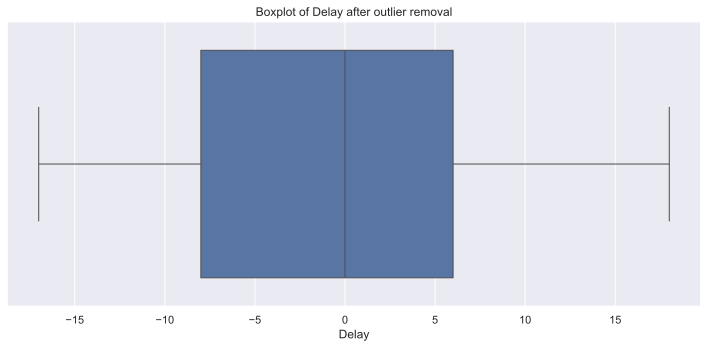

In [81]:
#plotting a boxplot of delay to see outlier values
plt.figure(figsize=(10,5))
sns.boxplot(x=df.delay, whis=3)
plt.title('Boxplot of Delay after outlier removal')
plt.xlabel('Delay')
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

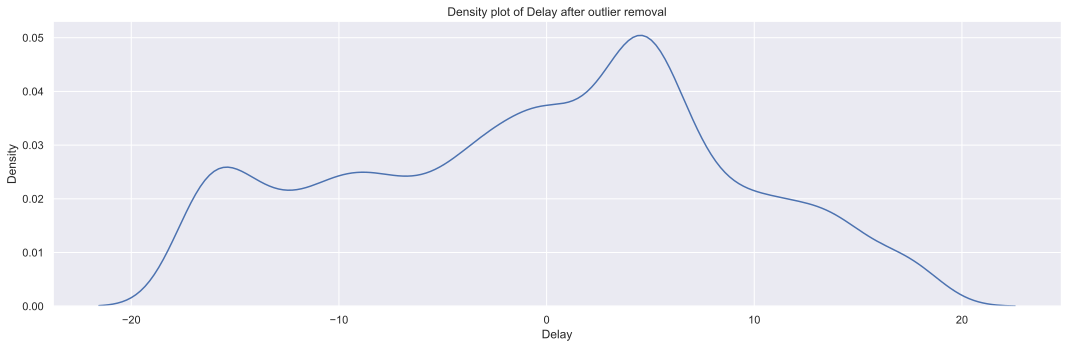

In [82]:
#plotting density plot of delay to see distribution
plt.figure(figsize=(10,5))
sns.displot(df.delay, kind='kde', aspect=3)
plt.title('Density plot of Delay after outlier removal')
plt.xlabel('Delay')
plt.tight_layout()
plt.show()

## Frequency Counts

In [83]:
df.fk_customer_map_id.nunique()

136

<Axes: xlabel='clearing_date', ylabel='count'>

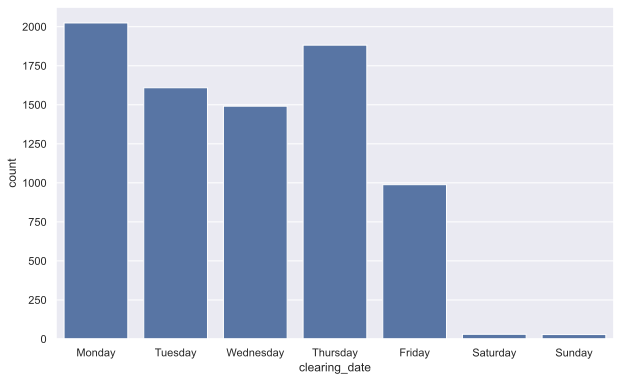

In [84]:
"""
Check frequency of payments done in week level, 
month level of the customers and check whether these freq counts are the same throughout the timeline.
If consistent then these are the cases of customers who make fixed no of payments per week/month 
"""
day_name = pd.Series(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
day = df['clearing_date'].dt.day_name()
sns.countplot(x=day, data=df, order=day_name)

<Axes: xlabel='clearing_date', ylabel='count'>

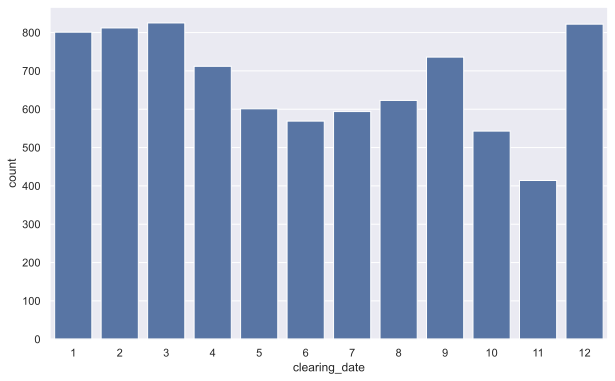

In [85]:
sns.countplot(x=df.clearing_date.dt.month)

In [86]:
amount_contribution = df.groupby('fk_customer_map_id')['amount'].sum().sort_values(ascending=False).to_frame(name='amount_Total').reset_index()
invoice_contribution = df.groupby('fk_customer_map_id')['cms_doc_header_id'].count().sort_values(ascending=False).to_frame(name='count').reset_index()
amount_contribution

,fk_customer_map_id,amount_Total
0,102923445,1.351549e+09
1,103024047,3.387571e+08
2,102865946,6.445462e+06
3,102986756,4.946263e+06
4,102919043,3.617624e+06
...,...,...
131,102884680,2.516400e+02
132,102906760,1.975200e+02
133,102876742,6.432000e+01
134,103035120,5.326000e+01


In [87]:
invoice_contribution

,fk_customer_map_id,count
0,102923445,1492
1,102906533,1390
2,103024047,1064
3,102988674,806
4,102865946,186
...,...,...
131,102871165,1
132,103035120,1
133,102986652,1
134,103032281,1


In [88]:
amount_top7 = amount_contribution.head(7)
invoice_top7 = invoice_contribution.head(7)
amount_top7

,fk_customer_map_id,amount_Total
0,102923445,1.351549e+09
1,103024047,3.387571e+08
2,102865946,6.445462e+06
3,102986756,4.946263e+06
4,102919043,3.617624e+06
5,103011086,3.181787e+06
6,102964750,2.850556e+06


In [89]:
invoice_top7

,fk_customer_map_id,count
0,102923445,1492
1,102906533,1390
2,103024047,1064
3,102988674,806
4,102865946,186
5,102900828,151
6,103070015,125


## Feature Engg

In [90]:
df.columns.to_list()

['cms_doc_header_id',
 'fk_customer_map_id',
 'amount',
 'due_date',
 'clearing_date',
 'create_date',
 'baseline_date_norm',
 'mega_date',
 'payment terms',
 'payment mode',
 'delay',
 'payment_time',
 'delay_bucket']

<Axes: xlabel='mega_date', ylabel='delay'>

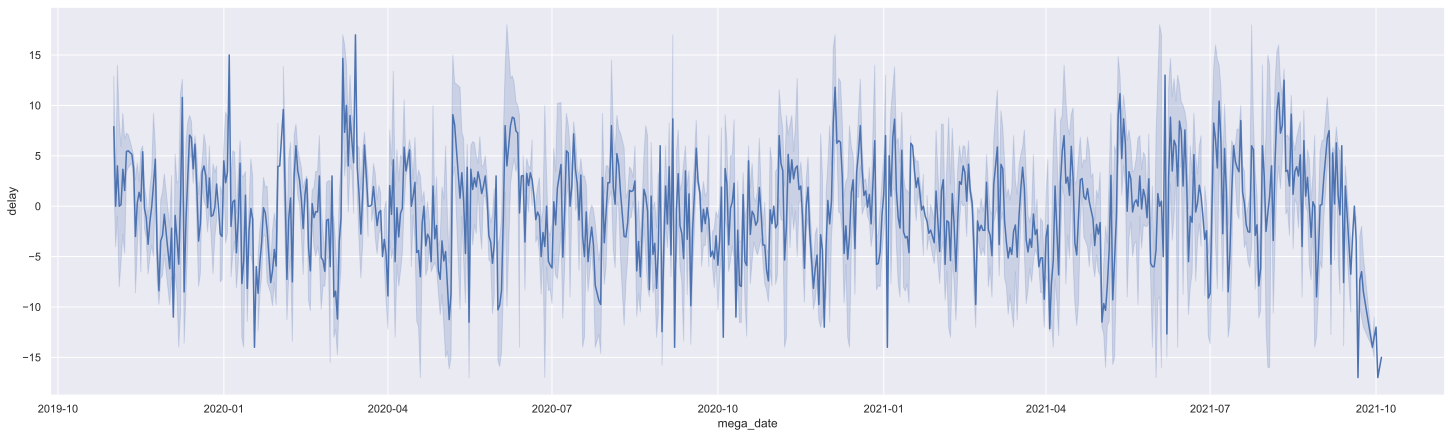

In [91]:
sns.set(rc={'figure.figsize':(25,7)})
sns.lineplot(x='mega_date',y='delay',data=dataframe)

In [92]:
df['megaMonth'] = df.mega_date.dt.month
df['clearingWeekDay'] = df.clearing_date.dt.weekday
df['closeDay'] = df.clearing_date.dt.day
df['payment_day_of_week'] = df['clearing_date'].dt.day

## Scoring functions

In [93]:
# Scoring Functions
def performScoringV2_weekend_excluded(test_df,scoring_actual_field, scoring_predicted_field, due_date_field, scoring_arguments):  
        report = []
        actuals = test_df[scoring_actual_field]
        predicted = test_df[scoring_predicted_field]
        due_date = test_df[due_date_field]
        test_data_len=len(test_df)
        days = scoring_arguments
        pred_rnd = np.round_(predicted)
        actual_payment_date = (due_date + pd.to_timedelta(actuals, unit='d'))
        predicted_payment_date = (due_date + pd.to_timedelta(pred_rnd, unit='d'))
        merror = mean_squared_error(actuals, predicted)
        RMSE = (merror**.5)
        report = "MSE :" + ' ' + str(np.around(merror,decimals=2)) + "\n" + "RMSE :" + ' ' + str(np.around(RMSE,decimals=2)) + " days" + "\n"
        
        # Calculating accuracy fordays
        for day in days:
            count = 0
            for j in zip(actual_payment_date,predicted_payment_date):
                if ((abs(np.busday_count(j[0].date(), j[1].date(), weekmask='Mon Tue Wed Thu Fri')) <= int(day))):
                    count += 1
            accuracy = (count / test_data_len * 100)
            append_string = "+/-" + str(day) + ' ' + 'Days' + " :" + ' ' + str(np.around(accuracy,decimals=2)) + "%" + "\n"
            report = report + append_string
        return report



In [94]:
df.shape

(8052, 17)

In [95]:
static = pd.get_dummies(df['payment terms'],prefix_sep='_',prefix='Code')
static1 = pd.get_dummies(df['payment mode'],prefix_sep='_',prefix='Mode')
df = pd.concat([df,static],axis=1)
df = pd.concat([df,static1],axis=1)


## SPLIT

In [96]:
df.mega_date.min(),df.mega_date.max()

(Timestamp('2019-11-01 00:00:00'), Timestamp('2021-10-04 00:00:00'))

In [97]:
new_data = df.copy()

In [98]:
history_date='2019-11-01'

train_start_date=history_date
train_end_date='2020-11-30'
val_start_date=train_end_date
val_end_date='2021-7-30'
test_start_date=val_end_date
test_end_date='2021-09-30'

df.sort_values(by='mega_date',inplace=True)

train = df[(df['mega_date']>=train_start_date)&(df['mega_date']<=train_end_date)]
val=df[(df['mega_date']>val_start_date)&(df['mega_date']<=val_end_date)]
test = df[(df['mega_date']>test_start_date)&(df['mega_date']<=test_end_date)]

train.shape,val.shape,test.shape

((5129, 29), (2518, 29), (401, 29))

In [99]:
print("\n\nTraining Data:")
print("Start date:",train.mega_date.min(),"\tEnd date:",train.mega_date.max())
print("\n\nValidation Data:")
print("Start date:",val.mega_date.min(),"\tEnd date:",val.mega_date.max())
print("\n\nTest Data:")
print("Start date:",test.mega_date.min(),"\tEnd date:",test.mega_date.max())



Training Data:
Start date: 2019-11-01 00:00:00 	End date: 2020-11-30 00:00:00


Validation Data:
Start date: 2020-12-01 00:00:00 	End date: 2021-07-30 00:00:00


Test Data:
Start date: 2021-07-31 00:00:00 	End date: 2021-09-30 00:00:00


## Train ,test,val Delay dist

<Axes: xlabel='delay', ylabel='Density'>

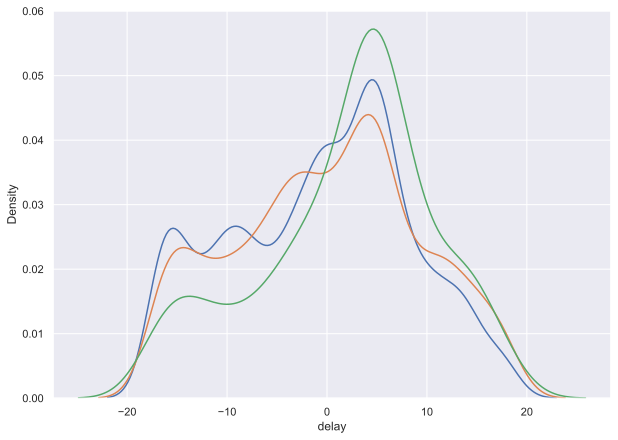

In [100]:
sns.set(rc={'figure.figsize':(10,7)}) 
sns.distplot(train.delay,hist=False,label="train")
sns.distplot(val.delay,hist=False,label="val")
sns.distplot(test.delay,hist=False,label="Test")

In [101]:
feats = train.columns.to_list()

In [102]:
feats

['cms_doc_header_id',
 'fk_customer_map_id',
 'amount',
 'due_date',
 'clearing_date',
 'create_date',
 'baseline_date_norm',
 'mega_date',
 'payment terms',
 'payment mode',
 'delay',
 'payment_time',
 'delay_bucket',
 'megaMonth',
 'clearingWeekDay',
 'closeDay',
 'payment_day_of_week',
 'Code_Z071',
 'Code_Z205',
 'Code_Z513',
 'Code_Z536',
 'Code_Z843',
 'Code_ZZ28',
 'Code_ZZ29',
 'Code_ZZ63',
 'Mode_Cash',
 'Mode_Cheque',
 'Mode_Credit Card',
 'Mode_Net banking']

In [103]:
len(feats)

29

In [104]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5129 entries, 676 to 1569
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   cms_doc_header_id    5129 non-null   int64         
 1   fk_customer_map_id   5129 non-null   int64         
 2   amount               5129 non-null   float64       
 3   due_date             5129 non-null   datetime64[ns]
 4   clearing_date        5129 non-null   datetime64[ns]
 5   create_date          5129 non-null   datetime64[ns]
 6   baseline_date_norm   5129 non-null   datetime64[ns]
 7   mega_date            5129 non-null   datetime64[ns]
 8   payment terms        5129 non-null   object        
 9   payment mode         5129 non-null   object        
 10  delay                5129 non-null   int64         
 11  payment_time         5129 non-null   int64         
 12  delay_bucket         5129 non-null   object        
 13  megaMonth            5129 non-null  

In [105]:
feats = train.columns.to_list()

In [106]:
feats

['cms_doc_header_id',
 'fk_customer_map_id',
 'amount',
 'due_date',
 'clearing_date',
 'create_date',
 'baseline_date_norm',
 'mega_date',
 'payment terms',
 'payment mode',
 'delay',
 'payment_time',
 'delay_bucket',
 'megaMonth',
 'clearingWeekDay',
 'closeDay',
 'payment_day_of_week',
 'Code_Z071',
 'Code_Z205',
 'Code_Z513',
 'Code_Z536',
 'Code_Z843',
 'Code_ZZ28',
 'Code_ZZ29',
 'Code_ZZ63',
 'Mode_Cash',
 'Mode_Cheque',
 'Mode_Credit Card',
 'Mode_Net banking']

## FEATURE SELECTION

In [107]:
features = [
 'cms_doc_header_id',
 'fk_customer_map_id',
 'amount',
 'payment_time',
 'megaMonth',
 'clearingWeekDay',
 'closeDay',
 'payment_day_of_week',
 'Code_Z071',
 'Code_Z205',
 'Code_Z513',
 'Code_Z536',
 'Code_Z843',
 'Code_ZZ28',
 'Code_ZZ29',
 'Code_ZZ63',
 'Mode_Cash',
 'Mode_Cheque',
 'Mode_Credit Card',
 'Mode_Net banking']

In [108]:
d = df.dtypes.tolist()
print(d)

[dtype('int64'), dtype('int64'), dtype('float64'), dtype('<M8[ns]'), dtype('<M8[ns]'), dtype('<M8[ns]'), dtype('<M8[ns]'), dtype('<M8[ns]'), dtype('O'), dtype('O'), dtype('int64'), dtype('int64'), dtype('O'), dtype('int32'), dtype('int32'), dtype('int32'), dtype('int32'), dtype('bool'), dtype('bool'), dtype('bool'), dtype('bool'), dtype('bool'), dtype('bool'), dtype('bool'), dtype('bool'), dtype('bool'), dtype('bool'), dtype('bool'), dtype('bool')]


In [109]:
import lightgbm as lgb
#Recursive Feature Elimination(RFE)
gbm = lgb.LGBMRegressor()
# create the RFE model and select 10 attributes
rfe = RFE(estimator=gbm,n_features_to_select=10)
rfe = rfe.fit(train[features],train['delay'])

# summarize the selection of the attributes
print(rfe.support_)



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000802 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 724
[LightGBM] [Info] Number of data points in the train set: 5129, number of used features: 19
[LightGBM] [Info] Start training from score -0.743615
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000663 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 722
[LightGBM] [Info] Number of data points in the train set: 5129, number of used features: 18
[LightGBM] [Info] Start training from score -0.743615
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000153 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins

In [110]:
rfe.get_support(indices = True)

array([ 0,  1,  2,  3,  4,  5,  6, 15, 16, 17], dtype=int64)

In [111]:
# summarize the ranking of the attributes
fea_rank_ = pd.DataFrame({'cols':train[features].columns, 'fea_rank':rfe.ranking_})
fea_rank_.loc[fea_rank_.fea_rank > 0].sort_values(by=['fea_rank'], ascending = True)

,cols,fea_rank
0,cms_doc_header_id,1
15,Code_ZZ63,1
16,Mode_Cash,1
6,closeDay,1
5,clearingWeekDay,1
17,Mode_Cheque,1
3,payment_time,1
2,amount,1
1,fk_customer_map_id,1
4,megaMonth,1


In [112]:
fea_rank_.sort_values(by='fea_rank',inplace=True,ascending=True)
fea_rank_.head(30)

,cols,fea_rank
0,cms_doc_header_id,1
15,Code_ZZ63,1
16,Mode_Cash,1
6,closeDay,1
5,clearingWeekDay,1
17,Mode_Cheque,1
3,payment_time,1
2,amount,1
1,fk_customer_map_id,1
4,megaMonth,1


In [113]:
sel_feats = [
'Code_ZZ63',
 'Code_ZZ29',
 'Code_ZZ28',
 'Code_Z536',
 'Code_Z513',
 'Mode_Cash',
 'Code_Z071',
 'closeDay',
 'clearingWeekDay',
    'megaMonth',
    'payment_time',
    'amount',
    'Mode_Cheque'
 ]

## LGBM Regressor 

In [114]:
model = lgb.LGBMRegressor()

model.fit(train[sel_feats],train['delay'])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 329
[LightGBM] [Info] Number of data points in the train set: 5129, number of used features: 13
[LightGBM] [Info] Start training from score -0.743615


LGBMRegressor()

In [115]:
# train['pred'] = model.predict(train[sel_feats])
# import numpy as np

# def rmse(predictions, targets):
#   return np.sqrt(((predictions - targets) ** 2).mean())

# def mse(predictions, targets):
#   return ((predictions - targets) ** 2).mean()
# print("RMSE:", rmse(train['pred'],train['delay'] ) )
# print("MSE:", mse(train['pred'],train['delay']))

In [116]:
train['pred'] = model.predict(train[sel_feats])
print("Train Score on V2:\n", performScoringV2_weekend_excluded(train, 'delay', 'pred', 'due_date', [0,3,5,7,9]))
print("--------------------------------------------------------------------")
val['pred'] = model.predict(val[sel_feats])
print("Val Score on V2:\n", performScoringV2_weekend_excluded(val, 'delay', 'pred', 'due_date', [0,3,5,7,9]))
print("--------------------------------------------------------------------")
test['pred'] = model.predict(test[sel_feats])
print("Test Score on V2:\n", performScoringV2_weekend_excluded(test, 'delay', 'pred', 'due_date', [0,3,5,7,9]))

Train Score on V2:
 MSE : 37.62
RMSE : 6.13 days
+/-0 Days : 8.07%
+/-3 Days : 57.61%
+/-5 Days : 77.29%
+/-7 Days : 89.39%
+/-9 Days : 96.55%

--------------------------------------------------------------------
Val Score on V2:
 MSE : 95.85
RMSE : 9.79 days
+/-0 Days : 4.05%
+/-3 Days : 38.48%
+/-5 Days : 54.77%
+/-7 Days : 68.94%
+/-9 Days : 80.3%

--------------------------------------------------------------------
Test Score on V2:
 MSE : 82.52
RMSE : 9.08 days
+/-0 Days : 5.99%
+/-3 Days : 37.41%
+/-5 Days : 56.61%
+/-7 Days : 69.83%
+/-9 Days : 83.79%



In [117]:
model2 = lgb.LGBMRegressor(boosting_type='gbdt', 
learning_rate=0.04, 
n_jobs=-1, 
num_leaves=37,
n_estimators= 500,
max_depth=20,
colsample_bytree = 0.75,
objective='regression_l1',
random_state =1)

model2.fit(train[sel_feats],train['delay'])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 329
[LightGBM] [Info] Number of data points in the train set: 5129, number of used features: 13


LGBMRegressor(colsample_bytree=0.75, learning_rate=0.04, max_depth=20,
              n_estimators=500, n_jobs=-1, num_leaves=37,
              objective='regression_l1', random_state=1)

In [118]:
train['pred'] = model2.predict(train[sel_feats])
print("Train Score on V2:\n", performScoringV2_weekend_excluded(train, 'delay', 'pred', 'due_date', [0,3,5,7,9]))
print("--------------------------------------------------------------------")
val['pred'] = model2.predict(val[sel_feats])
print("Val Score on V2:\n", performScoringV2_weekend_excluded(val, 'delay', 'pred', 'due_date', [0,3,5,7,9]))
print("--------------------------------------------------------------------")
test['pred'] = model2.predict(test[sel_feats])
print("Test Score on V2:\n", performScoringV2_weekend_excluded(test, 'delay', 'pred', 'due_date', [0,3,5,7,9]))

Train Score on V2:
 MSE : 38.22
RMSE : 6.18 days
+/-0 Days : 20.67%
+/-3 Days : 63.03%
+/-5 Days : 78.2%
+/-7 Days : 88.05%
+/-9 Days : 94.7%

--------------------------------------------------------------------
Val Score on V2:
 MSE : 92.12
RMSE : 9.6 days
+/-0 Days : 4.69%
+/-3 Days : 40.47%
+/-5 Days : 58.14%
+/-7 Days : 71.64%
+/-9 Days : 81.41%

--------------------------------------------------------------------
Test Score on V2:
 MSE : 85.12
RMSE : 9.23 days
+/-0 Days : 6.73%
+/-3 Days : 39.15%
+/-5 Days : 58.85%
+/-7 Days : 70.82%
+/-9 Days : 81.05%



In [119]:
df.shape

(8052, 29)

In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8052 entries, 676 to 6484
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   cms_doc_header_id    8052 non-null   int64         
 1   fk_customer_map_id   8052 non-null   int64         
 2   amount               8052 non-null   float64       
 3   due_date             8052 non-null   datetime64[ns]
 4   clearing_date        8052 non-null   datetime64[ns]
 5   create_date          8052 non-null   datetime64[ns]
 6   baseline_date_norm   8052 non-null   datetime64[ns]
 7   mega_date            8052 non-null   datetime64[ns]
 8   payment terms        8052 non-null   object        
 9   payment mode         8052 non-null   object        
 10  delay                8052 non-null   int64         
 11  payment_time         8052 non-null   int64         
 12  delay_bucket         8052 non-null   object        
 13  megaMonth            8052 non-null  

## Random Forest Regressor 

In [121]:
from sklearn.ensemble import RandomForestRegressor

In [122]:
model_rf = RandomForestRegressor( n_estimators=200, max_depth=10,random_state= 1)

In [123]:
model_rf.fit(train[sel_feats],train['delay'])

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=1)

In [124]:
train['pred'] = model_rf.predict(train[sel_feats])
print("Train Score on V2:\n", performScoringV2_weekend_excluded(train, 'delay', 'pred', 'due_date', [0,3,5,7,9]))
print("--------------------------------------------------------------------")
val['pred'] = model_rf.predict(val[sel_feats])
print("Val Score on V2:\n", performScoringV2_weekend_excluded(val, 'delay', 'pred', 'due_date', [0,3,5,7,9]))
print("--------------------------------------------------------------------")
test['pred'] = model_rf.predict(test[sel_feats])
print("Test Score on V2:\n", performScoringV2_weekend_excluded(test, 'delay', 'pred', 'due_date', [0,3,5,7,9]))

Train Score on V2:
 MSE : 35.85
RMSE : 5.99 days
+/-0 Days : 8.42%
+/-3 Days : 59.06%
+/-5 Days : 78.2%
+/-7 Days : 89.2%
+/-9 Days : 96.98%

--------------------------------------------------------------------
Val Score on V2:
 MSE : 88.27
RMSE : 9.4 days
+/-0 Days : 4.09%
+/-3 Days : 38.4%
+/-5 Days : 57.51%
+/-7 Days : 70.81%
+/-9 Days : 81.61%

--------------------------------------------------------------------
Test Score on V2:
 MSE : 83.95
RMSE : 9.16 days
+/-0 Days : 4.24%
+/-3 Days : 36.41%
+/-5 Days : 59.35%
+/-7 Days : 69.33%
+/-9 Days : 80.8%



## XGBoost Regressor

In [125]:
from xgboost import XGBRegressor

In [126]:
modelxg = XGBRegressor(n_estimators=200, max_depth=10, eta=0.1, subsample=0.7, colsample_bytree=0.8)

In [127]:
modelxg.fit(train[sel_feats],train['delay'])

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eta=0.1, eval_metric=None,
             feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [128]:
train['pred'] = modelxg.predict(train[sel_feats])
print("Train Score on V2:\n", performScoringV2_weekend_excluded(train, 'delay', 'pred', 'due_date', [0,3,5,7,9]))
print("--------------------------------------------------------------------")
val['pred'] = modelxg.predict(val[sel_feats])
print("Val Score on V2:\n", performScoringV2_weekend_excluded(val, 'delay', 'pred', 'due_date', [0,3,5,7,9]))
print("--------------------------------------------------------------------")
test['pred'] = modelxg.predict(test[sel_feats])
print("Test Score on V2:\n", performScoringV2_weekend_excluded(test, 'delay', 'pred', 'due_date', [0,3,5,7,9]))

Train Score on V2:
 MSE : 9.97
RMSE : 3.16 days
+/-0 Days : 26.11%
+/-3 Days : 86.96%
+/-5 Days : 95.93%
+/-7 Days : 98.62%
+/-9 Days : 99.77%

--------------------------------------------------------------------
Val Score on V2:
 MSE : 104.69
RMSE : 10.23 days
+/-0 Days : 3.85%
+/-3 Days : 33.76%
+/-5 Days : 50.68%
+/-7 Days : 67.79%
+/-9 Days : 79.47%

--------------------------------------------------------------------
Test Score on V2:
 MSE : 96.43
RMSE : 9.82 days
+/-0 Days : 4.99%
+/-3 Days : 36.66%
+/-5 Days : 55.86%
+/-7 Days : 68.83%
+/-9 Days : 79.8%



## CatBoost 

In [129]:
import catboost as cb 

In [130]:
#Pool used in CatBoost as a data structure to train model from
train_dataset = cb.Pool(train[sel_feats],train['delay']) #Pooling X_train and y_train into one single train_dataset



In [131]:
modelcb = cb.CatBoostRegressor() #Setting up the model CatBoostRegressor

In [ ]:
#Making the grid for the model this is done to do hyperparameter tuning
#Here i am using grid_search 
"""Grid search is a process that searches exhaustively 
through a manually specified subset of the hyperparameter space of the targeted algorithm"""

grid = {'iterations': [100, 150, 200,300],
        'learning_rate': [0.03, 0.1, 0.3],
        'depth': [4,6,8,10],
        'l2_leaf_reg': [0.2, 0.5, 1, 3]}

modelcb.grid_search(grid, train_dataset) #Passing the grid of the parameters to choose from and the dataset POOLED one

0:	learn: 9.1374966	test: 8.9414696	best: 8.9414696 (0)	total: 157ms	remaining: 15.5s
1:	learn: 9.1022372	test: 8.9116340	best: 8.9116340 (1)	total: 165ms	remaining: 8.06s
2:	learn: 9.0723578	test: 8.8880318	best: 8.8880318 (2)	total: 170ms	remaining: 5.5s
3:	learn: 9.0353170	test: 8.8569013	best: 8.8569013 (3)	total: 186ms	remaining: 4.45s
4:	learn: 9.0050962	test: 8.8305840	best: 8.8305840 (4)	total: 195ms	remaining: 3.71s
5:	learn: 8.9766214	test: 8.8056119	best: 8.8056119 (5)	total: 201ms	remaining: 3.15s
6:	learn: 8.9463023	test: 8.7816520	best: 8.7816520 (6)	total: 208ms	remaining: 2.77s
7:	learn: 8.9205331	test: 8.7615133	best: 8.7615133 (7)	total: 218ms	remaining: 2.5s
8:	learn: 8.8915091	test: 8.7364132	best: 8.7364132 (8)	total: 225ms	remaining: 2.28s
9:	learn: 8.8634516	test: 8.7143384	best: 8.7143384 (9)	total: 234ms	remaining: 2.11s
10:	learn: 8.8348756	test: 8.6915671	best: 8.6915671 (10)	total: 247ms	remaining: 2s
11:	learn: 8.8108165	test: 8.6742001	best: 8.6742001 (11)

In [140]:
modelc = cb.CatBoostRegressor( depth = 8,
  iterations = 300,
  learning_rate = 0.1,
  l2_leaf_reg = 0.2)

In [141]:
modelc.fit(train[sel_feats],train['delay']) 

0:	learn: 8.8970638	total: 5.47ms	remaining: 1.64s
1:	learn: 8.7540019	total: 10.3ms	remaining: 1.54s
2:	learn: 8.6250870	total: 16ms	remaining: 1.58s
3:	learn: 8.4926628	total: 20ms	remaining: 1.48s
4:	learn: 8.3851995	total: 24.6ms	remaining: 1.45s
5:	learn: 8.3070748	total: 28.7ms	remaining: 1.41s
6:	learn: 8.2420387	total: 32.6ms	remaining: 1.36s
7:	learn: 8.1616896	total: 36.4ms	remaining: 1.33s
8:	learn: 8.0933409	total: 40.6ms	remaining: 1.31s
9:	learn: 8.0421429	total: 44.1ms	remaining: 1.28s
10:	learn: 7.9940359	total: 47.6ms	remaining: 1.25s
11:	learn: 7.9400904	total: 51ms	remaining: 1.22s
12:	learn: 7.8970321	total: 54.7ms	remaining: 1.21s
13:	learn: 7.8595153	total: 58.7ms	remaining: 1.2s
14:	learn: 7.8103048	total: 62.2ms	remaining: 1.18s
15:	learn: 7.7570676	total: 65.9ms	remaining: 1.17s
16:	learn: 7.7245841	total: 69.8ms	remaining: 1.16s
17:	learn: 7.6798384	total: 73.9ms	remaining: 1.16s
18:	learn: 7.6426779	total: 77.4ms	remaining: 1.14s
19:	learn: 7.6153681	total: 8

In [142]:
train['pred'] = modelc.predict(train[sel_feats])
print("Train Score on V2:\n", performScoringV2_weekend_excluded(train, 'delay', 'pred', 'due_date', [0,3,5,7,9]))
print("--------------------------------------------------------------------")
val['pred'] = modelc.predict(val[sel_feats])
print("Val Score on V2:\n", performScoringV2_weekend_excluded(val, 'delay', 'pred', 'due_date', [0,3,5,7,9]))
print("--------------------------------------------------------------------")
test['pred'] = modelc.predict(test[sel_feats])
print("Test Score on V2:\n", performScoringV2_weekend_excluded(test, 'delay', 'pred', 'due_date', [0,3,5,7,9]))

Train Score on V2:
 MSE : 28.13
RMSE : 5.3 days
+/-0 Days : 9.61%
+/-3 Days : 64.26%
+/-5 Days : 83.31%
+/-7 Days : 92.77%
+/-9 Days : 98.58%

--------------------------------------------------------------------
Val Score on V2:
 MSE : 93.57
RMSE : 9.67 days
+/-0 Days : 4.05%
+/-3 Days : 37.69%
+/-5 Days : 55.12%
+/-7 Days : 70.53%
+/-9 Days : 80.94%

--------------------------------------------------------------------
Test Score on V2:
 MSE : 84.94
RMSE : 9.22 days
+/-0 Days : 5.74%
+/-3 Days : 36.91%
+/-5 Days : 57.61%
+/-7 Days : 70.32%
+/-9 Days : 82.04%



## AR vs Pred

In [143]:
from datetime import date, timedelta

In [144]:
temp = val['pred'].apply(np.ceil).apply(lambda x: pd.Timedelta(x, unit='D'))
val['predicted_clear_date'] = val['due_date'] + temp

In [145]:
temp = test['pred'].apply(np.ceil).apply(lambda x: pd.Timedelta(x, unit='D'))
test['predicted_clear_date'] = test['due_date'] + temp

In [146]:
test.head()

,cms_doc_header_id,fk_customer_map_id,amount,due_date,clearing_date,create_date,baseline_date_norm,mega_date,payment terms,payment mode,...,Code_Z843,Code_ZZ28,Code_ZZ29,Code_ZZ63,Mode_Cash,Mode_Cheque,Mode_Credit Card,Mode_Net banking,pred,predicted_clear_date
1978,287643,102988674,12.29,2021-08-30,2021-09-02,2021-07-29,2021-07-31,2021-07-31,Z205,Net banking,...,False,False,False,False,False,False,False,True,3.499381,2021-09-03
7493,5885476,102988674,679.26,2021-08-30,2021-09-02,2021-07-27,2021-07-31,2021-07-31,ZZ63,Cheque,...,False,False,False,True,False,True,False,False,3.307682,2021-09-03
4659,3308600,102923445,75.54,2021-08-31,2021-08-19,2021-07-26,2021-08-01,2021-08-01,ZZ29,Net banking,...,False,False,True,False,False,False,False,True,0.298305,2021-09-01
5067,7132588,102988674,34.44,2021-08-31,2021-09-07,2021-07-30,2021-08-01,2021-08-01,Z536,Net banking,...,False,False,False,False,False,False,False,True,-0.020582,2021-08-31
6220,264081,102944017,156.65,2021-09-01,2021-08-31,2021-07-28,2021-08-02,2021-08-02,ZZ29,Net banking,...,False,False,True,False,False,False,False,True,0.913051,2021-09-02
